# ADNI Hippocampus Volume and Surface Visualization

This notebook reads the outputs from `build_adni_hipp_ply_surfs.py` and builds analysis plots for AD/CN/MCI volume trends, longitudinal change, conversion groups, mesh QC, and optional 3D PLY inspection.

Run it after the conversion job finishes for final results. It can also be run while processing is ongoing; it will analyze whatever CSV rows are currently available.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import trimesh
import plotly.graph_objects as go
from IPython.display import display

try:
    import statsmodels.formula.api as smf
except Exception as exc:
    smf = None
    print(f"statsmodels unavailable: {exc}")

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid", context="notebook")

BASE_DIR = Path("/home/jakaria/ADNI/ADNI_1_GO_Large")
OUT_DIR = BASE_DIR / "adni_hipp_ply_surfs"
PLOTS_DIR = OUT_DIR / "notebook_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

DX_ORDER = ["CN", "MCI", "AD"]
DX_PALETTE = {"CN": "#2E86AB", "MCI": "#F18F01", "AD": "#C73E1D"}
CONVERSION_PALETTE = {
    "stable_CN": "#2E86AB",
    "stable_MCI": "#F18F01",
    "stable_AD": "#C73E1D",
    "CN_to_MCI": "#73A942",
    "CN_to_AD": "#7B2CBF",
    "CN_to_MCI_to_AD": "#5A189A",
    "MCI_to_AD": "#D1495B",
    "reverter_or_other": "#6C757D",
    "other_or_mixed": "#6C757D",
}

def savefig(name):
    path = PLOTS_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(path)

def month_from_viscode(value):
    if pd.isna(value):
        return np.nan
    value = str(value)
    if value == "bl":
        return 0
    if value.startswith("m") and value[1:].isdigit():
        return int(value[1:])
    return np.nan

print(f"Reading outputs from: {OUT_DIR}")

Reading outputs from: /home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs


## Load Data

In [2]:
csv_paths = {
    "clinical": OUT_DIR / "clean_clinical_longitudinal.csv",
    "merged": OUT_DIR / "clinical_volume_merged.csv",
    "long": OUT_DIR / "hipp_volumes_long.csv",
    "wide": OUT_DIR / "hipp_volumes_wide.csv",
    "subjects": OUT_DIR / "subject_conversion_summary.csv",
    "manifest": OUT_DIR / "mask_manifest.csv",
    "failed": OUT_DIR / "failed_conversions.csv",
    "run_summary": OUT_DIR / "run_summary.json",
}

missing = [name for name, path in csv_paths.items() if name != "run_summary" and not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing required output files: {missing}")

clinical = pd.read_csv(csv_paths["clinical"])
merged = pd.read_csv(csv_paths["merged"])
vol_long = pd.read_csv(csv_paths["long"])
vol_wide = pd.read_csv(csv_paths["wide"])
subjects = pd.read_csv(csv_paths["subjects"])
manifest = pd.read_csv(csv_paths["manifest"])
failed = pd.read_csv(csv_paths["failed"]) if csv_paths["failed"].exists() else pd.DataFrame()

for df in [clinical, merged, vol_long, vol_wide, subjects, manifest, failed]:
    if "RID" in df.columns:
        df["RID"] = df["RID"].astype(str)
    if "VISCODE" in df.columns:
        df["VISCODE"] = df["VISCODE"].astype(str)
    if "month_from_viscode" in df.columns:
        df["month_from_viscode"] = pd.to_numeric(df["month_from_viscode"], errors="coerce")

for col in ["AGE", "MMSE", "CDRSB", "ADAS11", "ADAS13", "APOE4", "Month.bl"]:
    if col in merged.columns:
        merged[col] = pd.to_numeric(merged[col], errors="coerce")

if csv_paths["run_summary"].exists():
    run_summary = json.loads(csv_paths["run_summary"].read_text())
else:
    run_summary = {}

summary_rows = [
    ("clinical labeled rows", len(clinical)),
    ("merged visit rows with volumes", len(merged)),
    ("long hemisphere volume rows", len(vol_long)),
    ("wide visit volume rows", len(vol_wide)),
    ("subject conversion rows", len(subjects)),
    ("mask manifest rows", len(manifest)),
    ("failed conversion rows", len(failed)),
]
display(pd.DataFrame(summary_rows, columns=["item", "count"]))
display(pd.Series(run_summary, name="run_summary").to_frame())

,item,count
0,clinical labeled rows,7651
1,merged visit rows with volumes,7645
2,long hemisphere volume rows,15296
3,wide visit volume rows,7645
4,subject conversion rows,1727
5,mask manifest rows,17322
6,failed conversion rows,12


,run_summary
base_dir,/home/jakaria/ADNI/ADNI_1_GO_Large
output_dir,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_p...
clinical_rows,7652
clean_clinical_rows,7651
mask_files,17322
queued_mask_files,15296
volume_rows,15296
merged_rows,7645
status_counts,"{'ok': 15264, 'skipped_existing': 20, 'failed'..."
sigma,1.2


## Data Readiness and Matching QC

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/01_data_readiness_qc.png


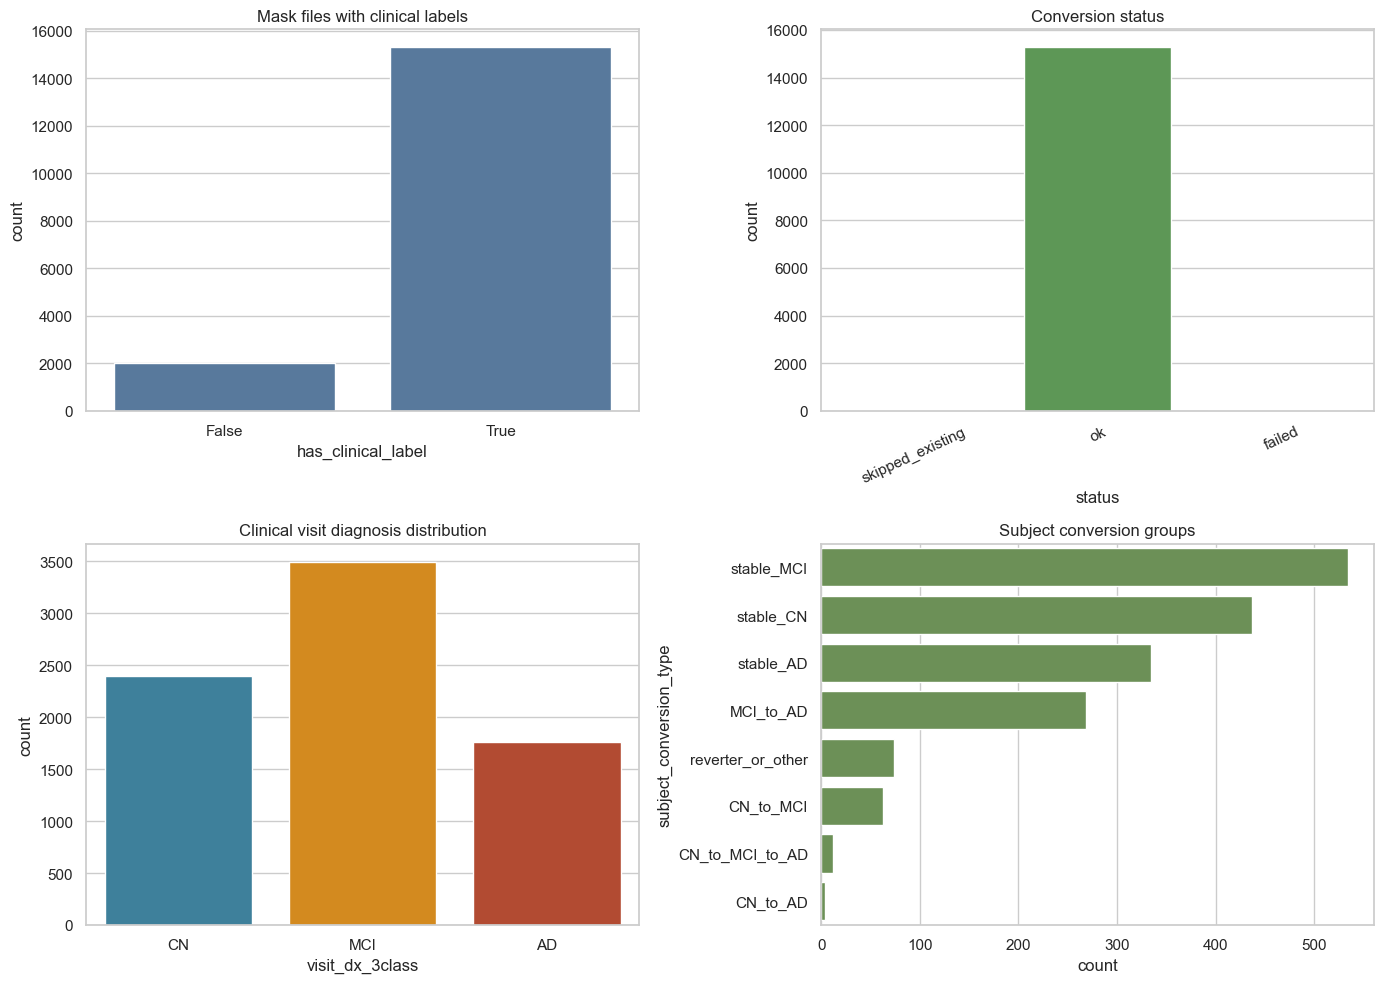


visits_by_dx


,count
visit_dx_3class,
MCI,3493
CN,2399
AD,1753



subjects_by_conversion


,count
subject_conversion_type,
stable_MCI,534
stable_CN,437
stable_AD,334
MCI_to_AD,269
reverter_or_other,74
CN_to_MCI,63
CN_to_MCI_to_AD,12
CN_to_AD,4



visits_by_viscode


,count
VISCODE,
bl,1724
m06,1456
m12,1404
m18,299
m24,1154
m36,475
m48,465
m60,200
m72,186


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if "has_clinical_label" in manifest.columns:
    sns.countplot(data=manifest, x="has_clinical_label", ax=axes[0, 0], color="#4C78A8")
    axes[0, 0].set_title("Mask files with clinical labels")
else:
    axes[0, 0].axis("off")

if "status" in vol_long.columns and not vol_long.empty:
    sns.countplot(data=vol_long, x="status", ax=axes[0, 1], color="#54A24B")
    axes[0, 1].set_title("Conversion status")
    axes[0, 1].tick_params(axis="x", rotation=25)
else:
    axes[0, 1].axis("off")

if "visit_dx_3class" in clinical.columns:
    sns.countplot(data=clinical, x="visit_dx_3class", order=DX_ORDER, palette=DX_PALETTE, hue="visit_dx_3class", legend=False, ax=axes[1, 0])
    axes[1, 0].set_title("Clinical visit diagnosis distribution")
else:
    axes[1, 0].axis("off")

if "subject_conversion_type" in subjects.columns:
    order = subjects["subject_conversion_type"].value_counts().index
    sns.countplot(data=subjects, y="subject_conversion_type", order=order, color="#6A994E", ax=axes[1, 1])
    axes[1, 1].set_title("Subject conversion groups")
else:
    axes[1, 1].axis("off")

savefig("01_data_readiness_qc")
plt.show()

tables = {}
if "visit_dx_3class" in merged.columns:
    tables["visits_by_dx"] = merged["visit_dx_3class"].value_counts(dropna=False)
if "subject_conversion_type" in subjects.columns:
    tables["subjects_by_conversion"] = subjects["subject_conversion_type"].value_counts(dropna=False)
if "VISCODE" in merged.columns:
    tables["visits_by_viscode"] = merged["VISCODE"].value_counts().sort_index(key=lambda idx: idx.map(month_from_viscode))

for name, table in tables.items():
    print(f"\n{name}")
    display(table.to_frame("count"))

## Baseline Volume Distributions

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/02_baseline_volume_distributions.png


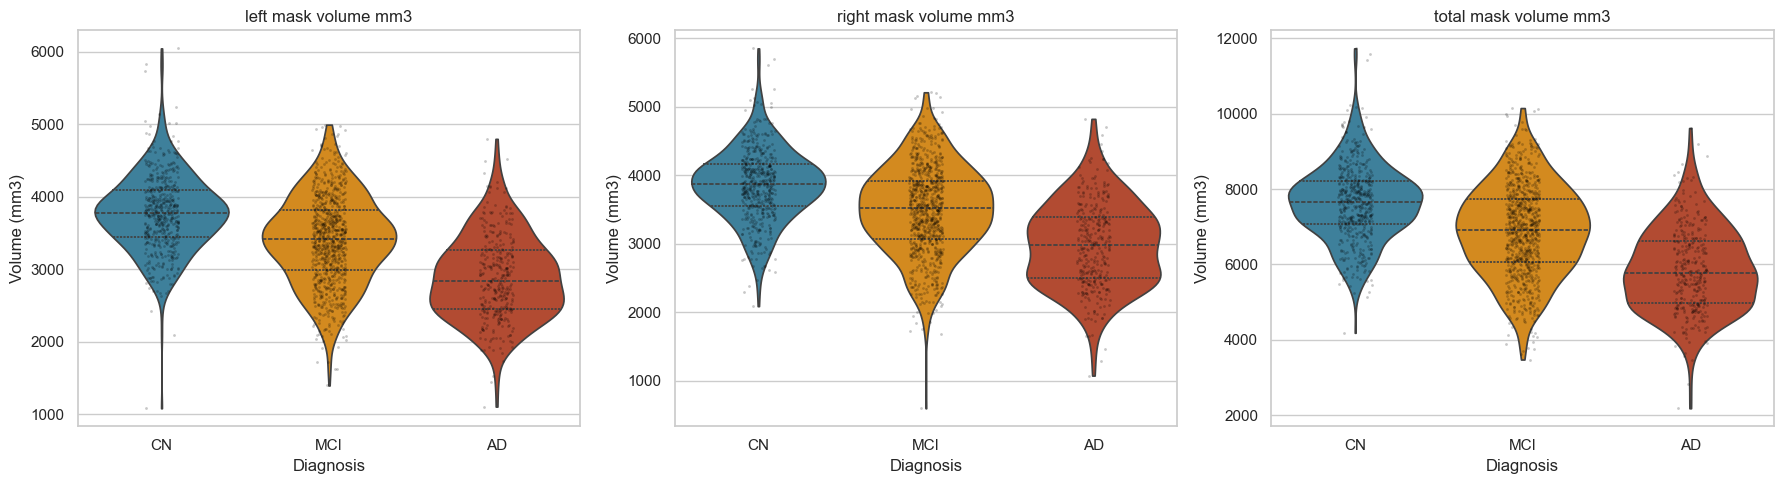

left_mask_volume_mm3                                                  right_mask_volume_mm3                                                   \
                               count         mean         std  median     min     max                 count         mean         std  median     min     max   
visit_dx_3class                                                                                                                                                
CN                               523  3771.108987  525.960477  3769.0  1083.0  6043.0                   523  3861.040153  526.015431  3878.0  2091.0  5854.0   
MCI                              863  3399.377752  613.887875  3412.0  1397.0  4992.0                   862  3495.261021  648.119046  3519.5   600.0  5213.0   
AD                               338  2887.150888  575.636037  2840.0  1106.0  4796.0                   338  2983.784024  619.588418  2989.0  1077.0  4825.0   

                total_mask_volume_mm3                                                     
                                count         mean          std  median     min      max  
visit_dx_3class                                                                           
CN                                523  7632.149140  1006.451349  7663.0  4186.0  11735.0  
MCI                               862  6894.547564  1212.827676  6924.0  3477.0  10151.0  
AD                                338  5870.934911  1116.880980  5775.0  2183.0   9621.0

In [4]:
baseline = merged[merged["VISCODE"].eq("bl")].copy()
mask_volume_cols = ["left_mask_volume_mm3", "right_mask_volume_mm3", "total_mask_volume_mm3"]
mesh_volume_cols = ["left_mesh_volume_mm3", "right_mesh_volume_mm3", "total_mesh_volume_mm3"]
volume_cols = mask_volume_cols
available_mesh_volume_cols = [col for col in mesh_volume_cols if col in merged.columns]
all_volume_cols = mask_volume_cols + available_mesh_volume_cols

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
for ax, col in zip(axes, volume_cols):
    if col not in baseline.columns:
        ax.axis("off")
        continue
    sns.violinplot(
        data=baseline,
        x="visit_dx_3class",
        y=col,
        order=DX_ORDER,
        palette=DX_PALETTE,
        hue="visit_dx_3class",
        legend=False,
        inner="quartile",
        cut=0,
        ax=ax,
    )
    sns.stripplot(
        data=baseline,
        x="visit_dx_3class",
        y=col,
        order=DX_ORDER,
        color="black",
        alpha=0.22,
        size=2,
        ax=ax,
    )
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("Diagnosis")
    ax.set_ylabel("Volume (mm3)")
savefig("02_baseline_volume_distributions")
plt.show()

baseline_summary = (
    baseline.groupby("visit_dx_3class")[volume_cols]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reindex(DX_ORDER)
)
display(baseline_summary)

## Mesh PLY Volume Distributions

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/03_baseline_mesh_volume_distributions.png


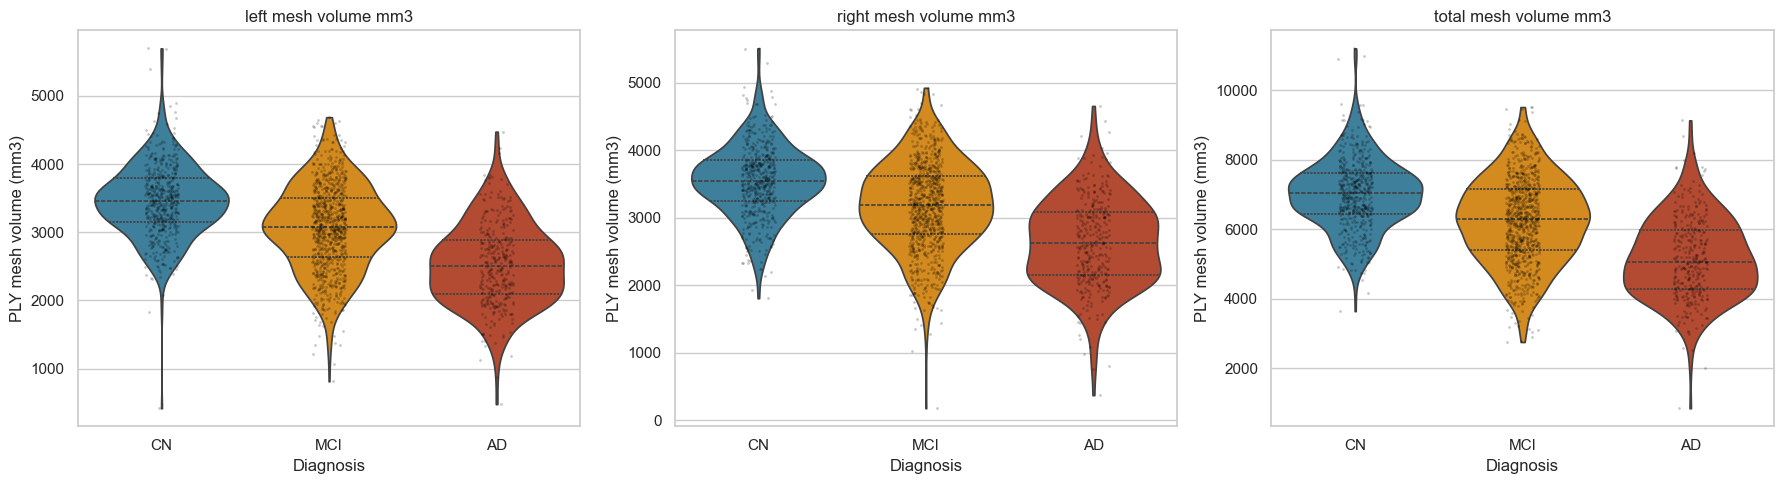

left_mesh_volume_mm3                                                                right_mesh_volume_mm3                                                     \
                               count         mean         std       median         min          max                 count         mean         std       median          min   
visit_dx_3class                                                                                                                                                                
CN                               523  3458.168709  535.337876  3464.751133  417.045750  5697.877808                   523  3546.428859  529.462719  3546.556638  1805.778926   
MCI                              862  3071.049581  632.676404  3072.326355  812.317573  4688.373132                   858  3172.422930  661.253635  3192.798146   175.546146   
AD                               338  2529.416153  600.392550  2506.050810  477.912948  4476.343640                   337  2632.761328  651.833230  2619.698909   369.530389   

                             total_mesh_volume_mm3                                                                    
                         max                 count         mean          std       median          min           max  
visit_dx_3class                                                                                                       
CN               5505.894420                   523  7004.597568  1016.468405  7035.624982  3641.266858  11199.367385  
MCI              4922.118099                   857  6243.647432  1241.825531  6281.566351  2753.240722   9511.743479  
AD               4653.191639                   337  5161.946710  1165.216854  5062.038048   847.443337   9129.535279

In [5]:
if available_mesh_volume_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
    for ax, col in zip(axes, mesh_volume_cols):
        if col not in baseline.columns:
            ax.axis("off")
            continue
        sns.violinplot(
            data=baseline,
            x="visit_dx_3class",
            y=col,
            order=DX_ORDER,
            palette=DX_PALETTE,
            hue="visit_dx_3class",
            legend=False,
            inner="quartile",
            cut=0,
            ax=ax,
        )
        sns.stripplot(
            data=baseline,
            x="visit_dx_3class",
            y=col,
            order=DX_ORDER,
            color="black",
            alpha=0.22,
            size=2,
            ax=ax,
        )
        ax.set_title(col.replace("_", " "))
        ax.set_xlabel("Diagnosis")
        ax.set_ylabel("PLY mesh volume (mm3)")
    savefig("03_baseline_mesh_volume_distributions")
    plt.show()

    mesh_baseline_summary = (
        baseline.groupby("visit_dx_3class")[available_mesh_volume_cols]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reindex(DX_ORDER)
    )
    display(mesh_baseline_summary)
else:
    print("No mesh volume columns available yet.")

## Mask Volume Versus Mesh PLY Volume

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/04_mask_vs_mesh_volume_bias.png


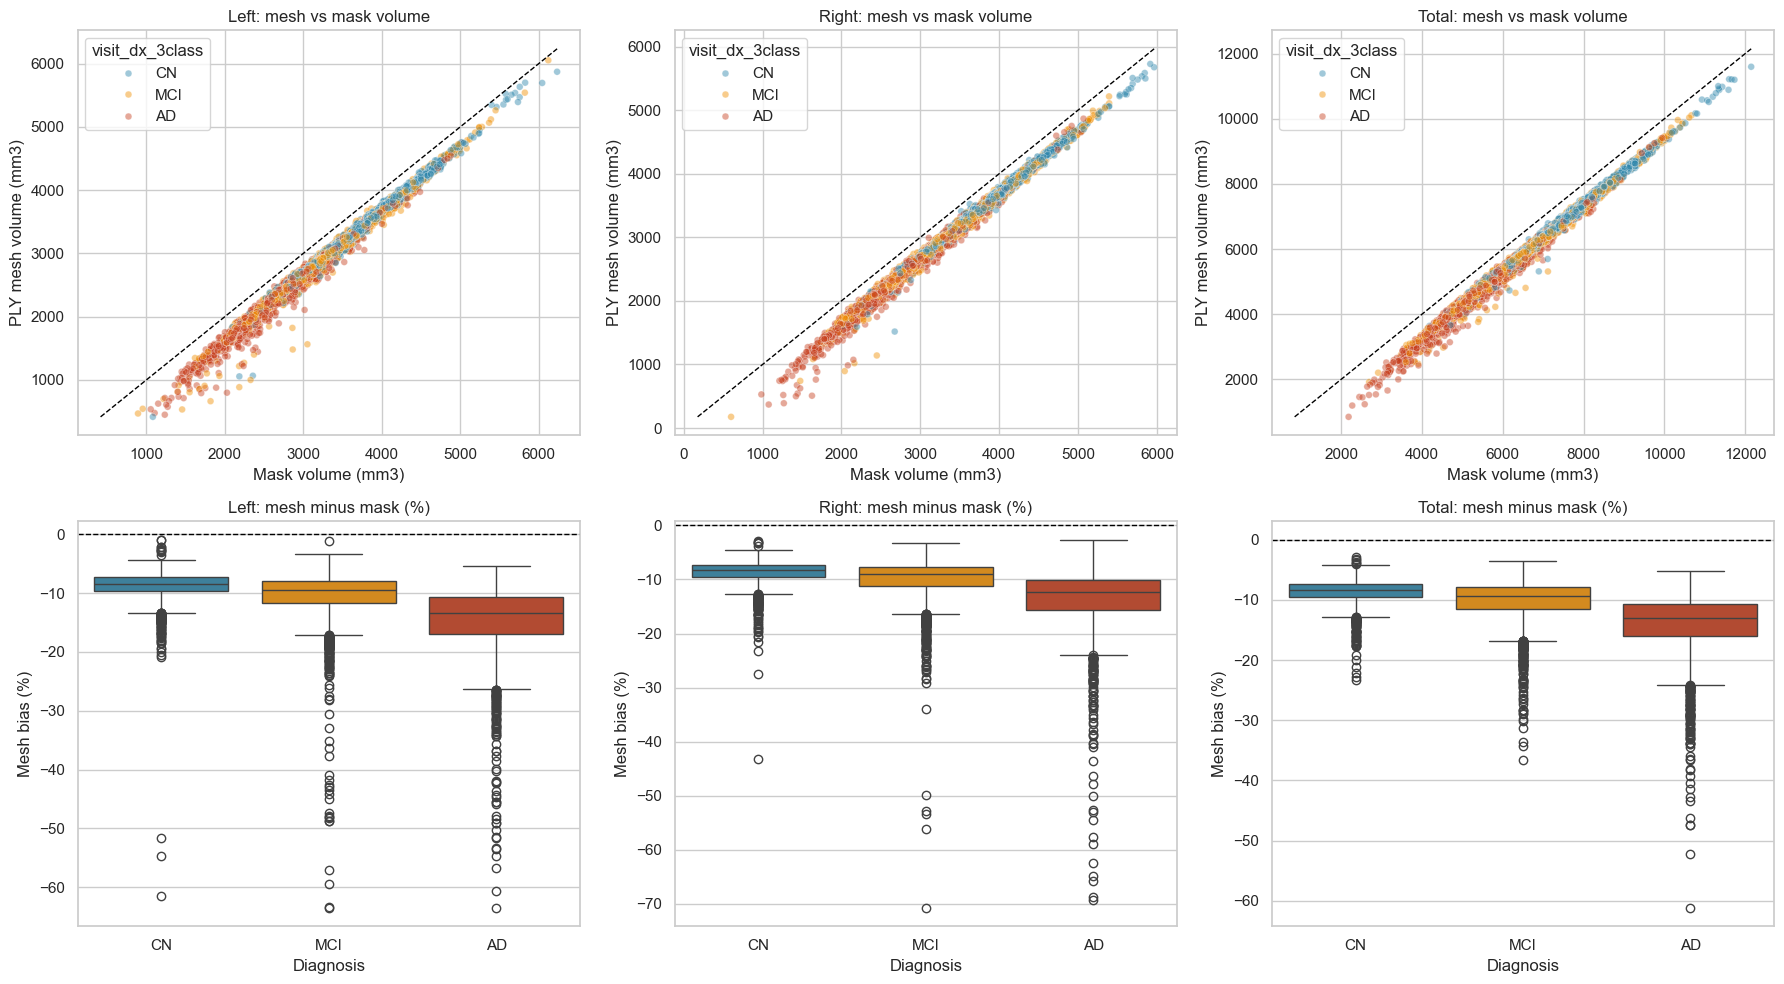

left_mesh_minus_mask_mm3                                    right_mesh_minus_mask_mm3                                    total_mesh_minus_mask_mm3              \
                                   count        mean        std      median                     count        mean        std      median                     count        mean   
visit_dx_3class                                                                                                                                                                  
CN                                  2397 -315.102460  55.599559 -309.602083                      2395 -315.008051  47.094903 -311.490821                      2393 -630.143830   
MCI                                 3490 -332.328446  73.713080 -323.656074                      3479 -325.144736  57.153254 -319.653651                      3476 -657.485369   
AD                                  1750 -379.571553  97.608271 -359.867670                      1750 -363.813806  85.953224 -351.012203                      1747 -743.430546   

                                        left_mesh_minus_mask_pct                                 right_mesh_minus_mask_pct                                  \
                        std      median                    count       mean       std     median                     count       mean       std     median   
visit_dx_3class                                                                                                                                              
CN                85.039147 -622.392871                     2397  -8.780803  2.702674  -8.388210                      2395  -8.605013  2.186997  -8.260716   
MCI              107.873487 -644.144226                     3490 -10.367463  4.233223  -9.501935                      3479  -9.887633  3.594768  -9.074209   
AD               153.410704 -716.068229                     1750 -14.789115  6.555833 -13.316901                      1750 -13.882586  6.511413 -12.387868   

                total_mesh_minus_mask_pct                                  
                                    count       mean       std     median  
visit_dx_3class                                                            
CN                                   2393  -8.659221  1.967498  -8.374641  
MCI                                  3476 -10.053580  3.175184  -9.318234  
AD                                   1747 -14.189863  5.585134 -13.067730

In [6]:
comparison_pairs = [
    ("left_mask_volume_mm3", "left_mesh_volume_mm3", "left"),
    ("right_mask_volume_mm3", "right_mesh_volume_mm3", "right"),
    ("total_mask_volume_mm3", "total_mesh_volume_mm3", "total"),
]
comparison_pairs = [(mask_col, mesh_col, label) for mask_col, mesh_col, label in comparison_pairs if mask_col in merged.columns and mesh_col in merged.columns]

mesh_bias = merged.copy()
for mask_col, mesh_col, label in comparison_pairs:
    mesh_bias[f"{label}_mesh_minus_mask_mm3"] = mesh_bias[mesh_col] - mesh_bias[mask_col]
    mesh_bias[f"{label}_mesh_minus_mask_pct"] = 100.0 * mesh_bias[f"{label}_mesh_minus_mask_mm3"] / mesh_bias[mask_col].replace(0, np.nan)

if comparison_pairs:
    fig, axes = plt.subplots(2, len(comparison_pairs), figsize=(6 * len(comparison_pairs), 10), squeeze=False)
    for col_idx, (mask_col, mesh_col, label) in enumerate(comparison_pairs):
        ax = axes[0, col_idx]
        sns.scatterplot(
            data=mesh_bias,
            x=mask_col,
            y=mesh_col,
            hue="visit_dx_3class",
            hue_order=DX_ORDER,
            palette=DX_PALETTE,
            alpha=0.45,
            s=24,
            ax=ax,
        )
        low = np.nanmin(mesh_bias[[mask_col, mesh_col]].values)
        high = np.nanmax(mesh_bias[[mask_col, mesh_col]].values)
        ax.plot([low, high], [low, high], color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{label.title()}: mesh vs mask volume")
        ax.set_xlabel("Mask volume (mm3)")
        ax.set_ylabel("PLY mesh volume (mm3)")

        ax = axes[1, col_idx]
        pct_col = f"{label}_mesh_minus_mask_pct"
        sns.boxplot(
            data=mesh_bias,
            x="visit_dx_3class",
            y=pct_col,
            order=DX_ORDER,
            palette=DX_PALETTE,
            hue="visit_dx_3class",
            legend=False,
            ax=ax,
        )
        ax.axhline(0, color="black", linewidth=1, linestyle="--")
        ax.set_title(f"{label.title()}: mesh minus mask (%)")
        ax.set_xlabel("Diagnosis")
        ax.set_ylabel("Mesh bias (%)")
    savefig("04_mask_vs_mesh_volume_bias")
    plt.show()

    bias_cols = [f"{label}_mesh_minus_mask_mm3" for _, _, label in comparison_pairs] + [f"{label}_mesh_minus_mask_pct" for _, _, label in comparison_pairs]
    display(mesh_bias.groupby("visit_dx_3class")[bias_cols].agg(["count", "mean", "std", "median"]).reindex(DX_ORDER))
else:
    print("No matching mask and mesh volume columns available.")

## Volume Versus Age

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/03_volume_vs_age_by_diagnosis.png


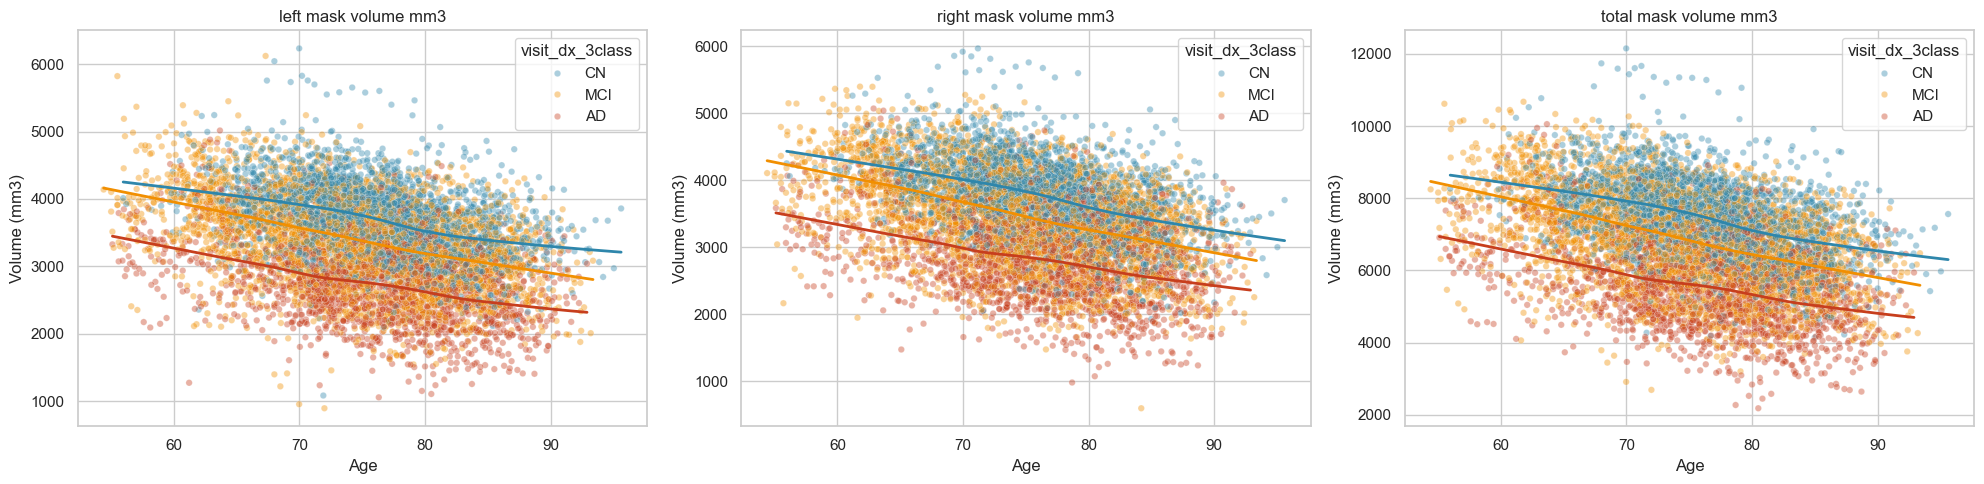

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, col in zip(axes, volume_cols):
    if col not in merged.columns:
        ax.axis("off")
        continue
    sns.scatterplot(
        data=merged,
        x="AGE",
        y=col,
        hue="visit_dx_3class",
        hue_order=DX_ORDER,
        palette=DX_PALETTE,
        alpha=0.40,
        s=22,
        ax=ax,
    )
    for dx in DX_ORDER:
        sub = merged[merged["visit_dx_3class"].eq(dx)]
        if len(sub) > 20:
            sns.regplot(
                data=sub,
                x="AGE",
                y=col,
                scatter=False,
                lowess=True,
                color=DX_PALETTE[dx],
                line_kws={"linewidth": 2},
                ax=ax,
            )
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("Age")
    ax.set_ylabel("Volume (mm3)")
savefig("03_volume_vs_age_by_diagnosis")
plt.show()

## Mesh PLY Volume Versus Age

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/05_mesh_volume_vs_age_by_diagnosis.png


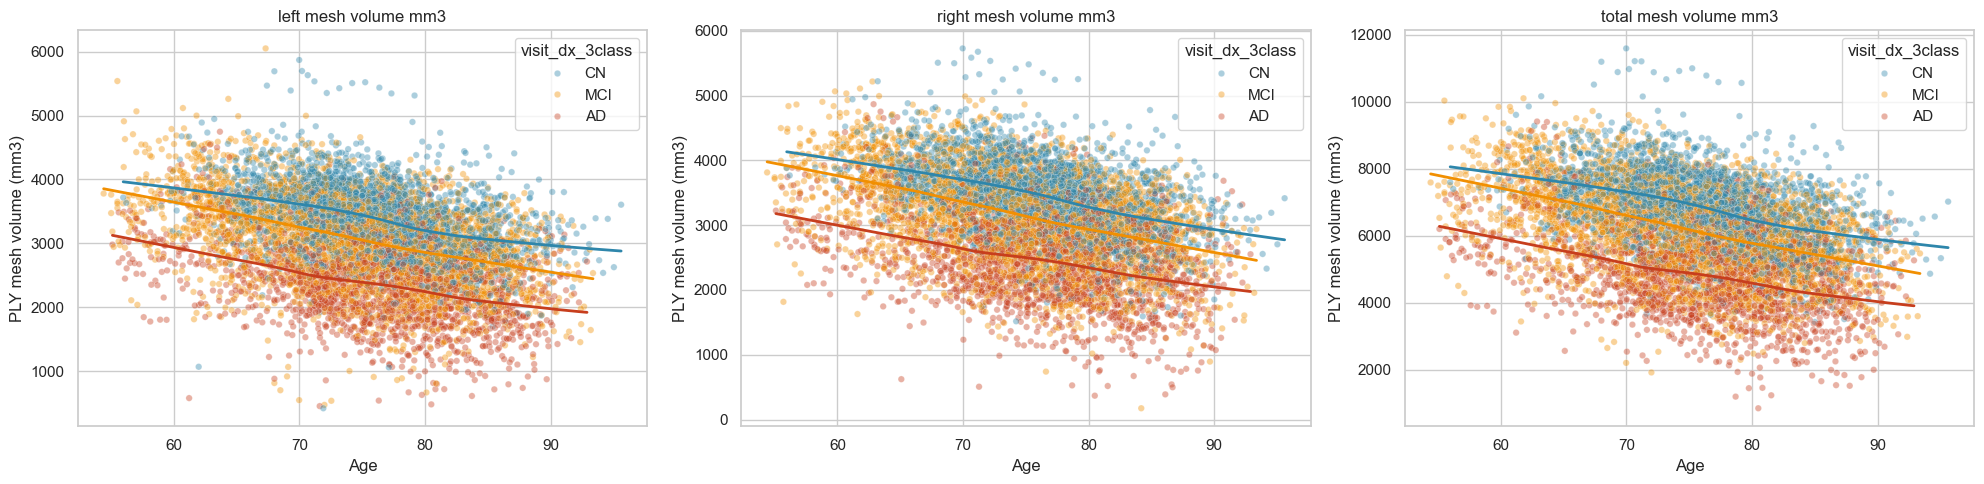

In [8]:
if available_mesh_volume_cols:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for ax, col in zip(axes, mesh_volume_cols):
        if col not in merged.columns:
            ax.axis("off")
            continue
        sns.scatterplot(
            data=merged,
            x="AGE",
            y=col,
            hue="visit_dx_3class",
            hue_order=DX_ORDER,
            palette=DX_PALETTE,
            alpha=0.40,
            s=22,
            ax=ax,
        )
        for dx in DX_ORDER:
            sub = merged[merged["visit_dx_3class"].eq(dx)]
            if len(sub) > 20:
                sns.regplot(
                    data=sub,
                    x="AGE",
                    y=col,
                    scatter=False,
                    lowess=True,
                    color=DX_PALETTE[dx],
                    line_kws={"linewidth": 2},
                    ax=ax,
                )
        ax.set_title(col.replace("_", " "))
        ax.set_xlabel("Age")
        ax.set_ylabel("PLY mesh volume (mm3)")
    savefig("05_mesh_volume_vs_age_by_diagnosis")
    plt.show()
else:
    print("No mesh volume columns available yet.")

## Longitudinal Mean Trends

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/04_mean_longitudinal_volume_by_diagnosis.png


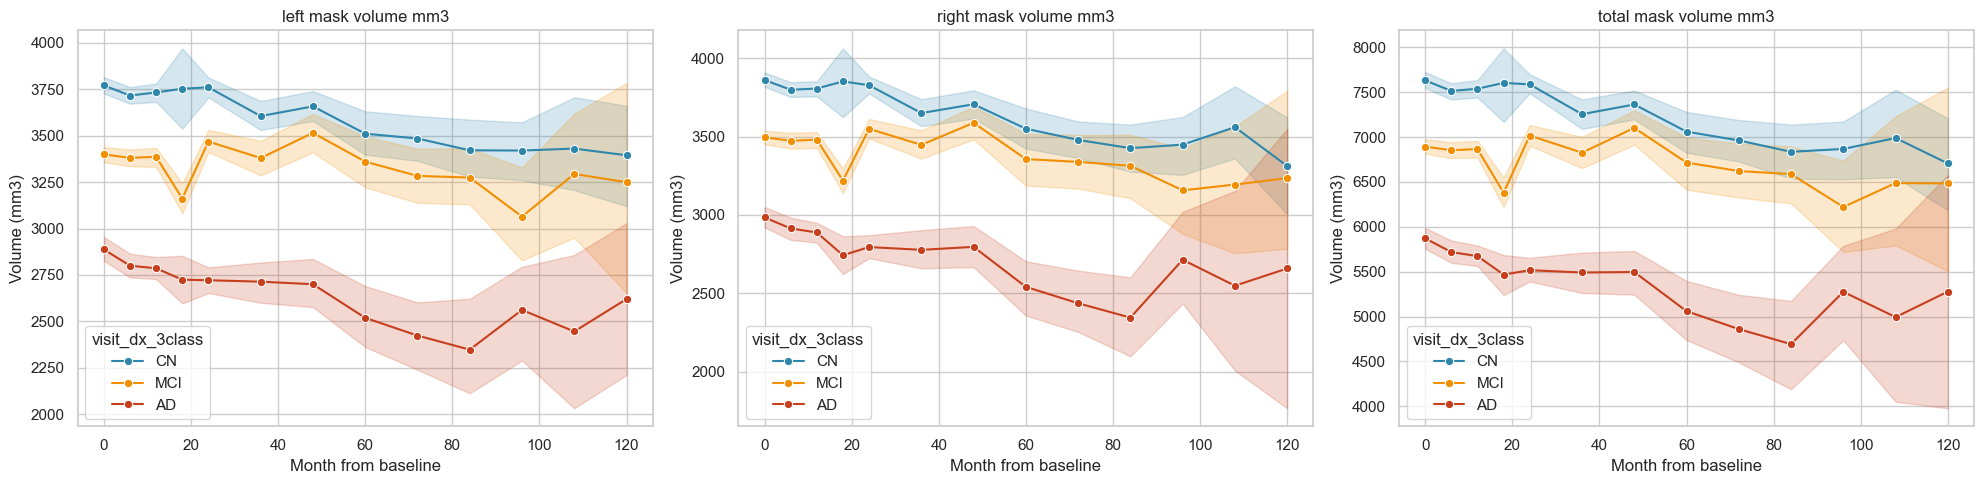

visit_dx_3class month_from_viscode left_mask_volume_mm3                                  right_mask_volume_mm3                                   total_mask_volume_mm3  \
                                                     count         mean         std  median                 count         mean          std  median                 count   
0               AD                0.0                  338  2887.150888  575.636037  2840.0                   338  2983.784024   619.588418  2989.0                   338   
1               AD                6.0                  312  2799.798077  574.618191  2785.5                   310  2913.709677   618.192699  2838.5                   310   
2               AD               12.0                  344  2785.729651  581.932715  2739.0                   344  2887.898256   616.770049  2869.0                   344   
3               AD               18.0                   84  2724.547619  585.537163  2704.0                    84  2742.607143   561.766641  2721.5                    84   
4               AD               24.0                  301  2721.392027  621.625090  2659.0                   301  2794.910299   658.132921  2719.0                   301   
5               AD               36.0                  110  2713.745455  586.049822  2731.5                   110  2777.063636   653.863666  2795.5                   110   
6               AD               48.0                  105  2700.038095  673.647619  2636.0                   105  2796.076190   689.541984  2722.0                   105   
7               AD               60.0                   52  2518.865385  620.698121  2476.5                    52  2540.750000   644.479540  2539.5                    52   
8               AD               72.0                   44  2423.340909  630.796984  2336.5                    44  2436.136364   652.878976  2404.5                    44   
9               AD               84.0                   27  2347.370370  724.435756  2195.0                    27  2344.518519   656.785375  2284.0                    27   
10              AD               96.0                   23  2561.434783  650.580358  2593.0                    23  2713.826087   728.180775  2558.0                    23   
11              AD              108.0                   11  2445.272727  731.700634  2451.0                    11  2548.090909   990.147005  2528.0                    11   
12              AD              120.0                    2  2620.000000  578.413347  2620.0                     2  2658.000000  1261.478498  2658.0                     2   
13              CN                0.0                  523  3771.108987  525.960477  3769.0                   523  3861.040153   526.015431  3878.0                   523   
14              CN                6.0                  405  3716.385185  485.260535  3750.0                   405  3798.765432   511.537105  3851.0                   405   
15              CN               12.0                  410  3733.258537  502.125343  3745.0                   410  3806.548780   538.116055  3847.5                   410   
16              CN               18.0                   10  3753.200000  379.869802  3732.0                    10  3851.900000   376.906841  3922.0                    10   
17              CN               24.0                  408  3760.747549  554.800323  3746.0                   408  3827.666667   575.670968  3845.0                   408   
18              CN               36.0                  173  3605.895954  554.337579  3576.0                   173  3650.000000   571.618856  3680.0                   173   
19              CN               48.0                  182  3658.186813  560.881979  3678.0                   182  3706.230769   598.326323  3755.5                   182   
20              CN               60.0                   85  3510.988235  542.229052  3496.0                    85  3550.317647   587.126765  3569.0                    85   
21              CN      

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True)
for ax, col in zip(axes, volume_cols):
    if col not in merged.columns:
        ax.axis("off")
        continue
    sns.lineplot(
        data=merged,
        x="month_from_viscode",
        y=col,
        hue="visit_dx_3class",
        hue_order=DX_ORDER,
        palette=DX_PALETTE,
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        ax=ax,
    )
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("Month from baseline")
    ax.set_ylabel("Volume (mm3)")
savefig("04_mean_longitudinal_volume_by_diagnosis")
plt.show()

longitudinal_summary = (
    merged.groupby(["visit_dx_3class", "month_from_viscode"])[volume_cols]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
)
display(longitudinal_summary.head(30))

## Mesh PLY Longitudinal Mean Trends

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/06_mean_longitudinal_mesh_volume_by_diagnosis.png


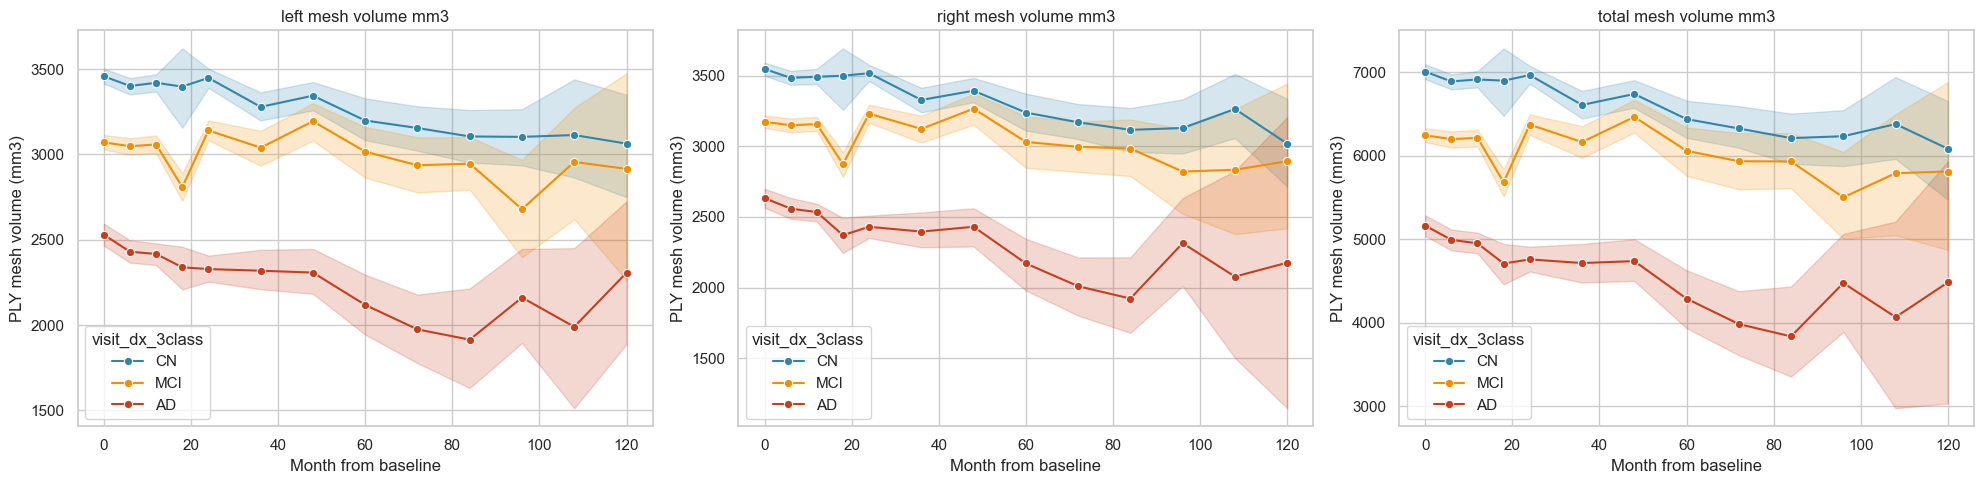

visit_dx_3class month_from_viscode left_mesh_volume_mm3                                       right_mesh_volume_mm3                                         \
                                                     count         mean         std       median                 count         mean          std       median   
0               AD                0.0                  338  2529.416153  600.392550  2506.050810                   337  2632.761328   651.833230  2619.698909   
1               AD                6.0                  311  2429.946885  597.535882  2455.298520                   310  2558.219046   651.336579  2514.640560   
2               AD               12.0                  342  2416.726447  599.498064  2414.392805                   344  2533.674596   643.043249  2528.872382   
3               AD               18.0                   84  2338.581570  592.273580  2366.986551                    84  2370.112293   571.023685  2427.676884   
4               AD               24.0                  301  2328.284259  664.439864  2290.841344                   301  2429.765811   685.306308  2361.979350   
5               AD               36.0                  110  2318.643073  619.861062  2333.368638                   110  2395.638926   689.487993  2407.781768   
6               AD               48.0                  105  2307.717971  703.504514  2291.360611                   105  2429.835159   716.691482  2383.051673   
7               AD               60.0                   52  2118.067602  660.482829  2015.565208                    52  2170.572482   689.134146  2260.213228   
8               AD               72.0                   44  1974.719498  682.321395  1899.445727                    44  2009.321165   718.687305  2060.955934   
9               AD               84.0                   27  1914.391246  806.791667  1823.139757                    27  1921.920369   702.770954  1817.442250   
10              AD               96.0                   23  2161.309618  708.936742  2260.553818                    23  2313.925607   795.960840  2225.391394   
11              AD              108.0                   11  1989.639075  836.094729  2059.179386                    11  2077.345325  1128.208565  2174.650973   
12              AD              120.0                    2  2306.884642  591.607656  2306.884642                     2  2175.777029  1456.527423  2175.777029   
13              CN                0.0                  523  3458.168709  535.337876  3464.751133                   523  3546.428859   529.462719  3546.556638   
14              CN                6.0                  405  3401.870040  495.307509  3419.519840                   403  3483.615237   513.968670  3523.044033   
15              CN               12.0                  410  3420.188778  513.335021  3434.177669                   410  3491.012932   550.893254  3544.336466   
16              CN               18.0                   10  3398.062039  391.774432  3431.636840                    10  3498.509310   377.036478  3526.896497   
17              CN               24.0                  406  3449.095962  574.179886  3440.219801                   407  3516.473939   587.599747  3518.977061   
18              CN               36.0                  173  3279.124298  571.923688  3254.413117                   173  3327.099912   577.795882  3368.358865   
19              CN               48.0                  182  3344.706608  576.844702  3379.573714                   182  3392.499818   612.679073  3454.644478   
20              CN               60.0                   85  3199.191859  567.529425  3138.624971                    85  3237.787991   606.404420  3262.496645   
21              CN               72.0                   79  3155.203246  595.320018  3158.654971                    79  3169.270797   569.362292  3163.049822   
22              CN               84.0                   58  3105.707599  627.272894  3015.932578                    57  3115.489392   617.0

In [10]:
if available_mesh_volume_cols:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True)
    for ax, col in zip(axes, mesh_volume_cols):
        if col not in merged.columns:
            ax.axis("off")
            continue
        sns.lineplot(
            data=merged,
            x="month_from_viscode",
            y=col,
            hue="visit_dx_3class",
            hue_order=DX_ORDER,
            palette=DX_PALETTE,
            estimator="mean",
            errorbar=("ci", 95),
            marker="o",
            ax=ax,
        )
        ax.set_title(col.replace("_", " "))
        ax.set_xlabel("Month from baseline")
        ax.set_ylabel("PLY mesh volume (mm3)")
    savefig("06_mean_longitudinal_mesh_volume_by_diagnosis")
    plt.show()

    mesh_longitudinal_summary = (
        merged.groupby(["visit_dx_3class", "month_from_viscode"])[available_mesh_volume_cols]
        .agg(["count", "mean", "std", "median"])
        .reset_index()
    )
    display(mesh_longitudinal_summary.head(30))
else:
    print("No mesh volume columns available yet.")

## Subject Trajectories

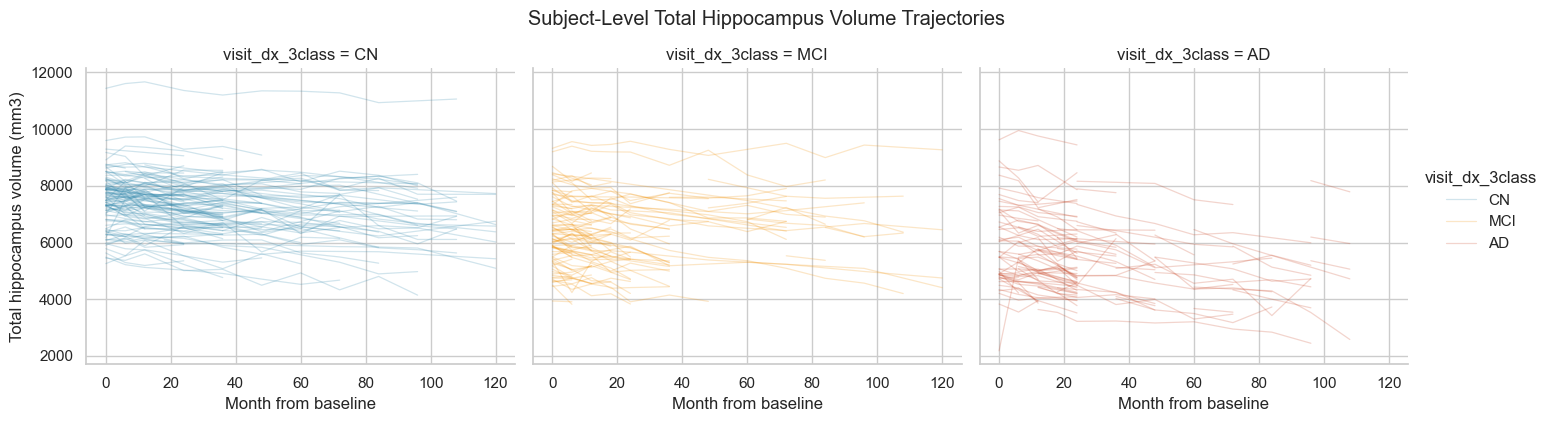

In [11]:
def sample_subjects(df, max_per_group=120, group_col="visit_dx_3class"):
    parts = []
    for group_name, group in df.groupby(group_col, sort=False):
        rids = sorted(group["RID"].dropna().unique(), key=lambda x: int(x) if str(x).isdigit() else 10**12)
        rids = rids[:max_per_group]
        parts.append(group[group["RID"].isin(rids)])
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

spaghetti = sample_subjects(merged.dropna(subset=["total_mask_volume_mm3"]), max_per_group=120)
if not spaghetti.empty:
    grid = sns.relplot(
        data=spaghetti,
        x="month_from_viscode",
        y="total_mask_volume_mm3",
        col="visit_dx_3class",
        col_order=DX_ORDER,
        hue="visit_dx_3class",
        hue_order=DX_ORDER,
        units="RID",
        estimator=None,
        kind="line",
        palette=DX_PALETTE,
        alpha=0.22,
        linewidth=0.9,
        height=4,
        aspect=1.2,
    )
    grid.set_axis_labels("Month from baseline", "Total hippocampus volume (mm3)")
    grid.fig.suptitle("Subject-Level Total Hippocampus Volume Trajectories", y=1.05)
    grid.fig.savefig(PLOTS_DIR / "05_subject_spaghetti_by_diagnosis.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("No trajectory data available.")

## Mesh PLY Subject Trajectories

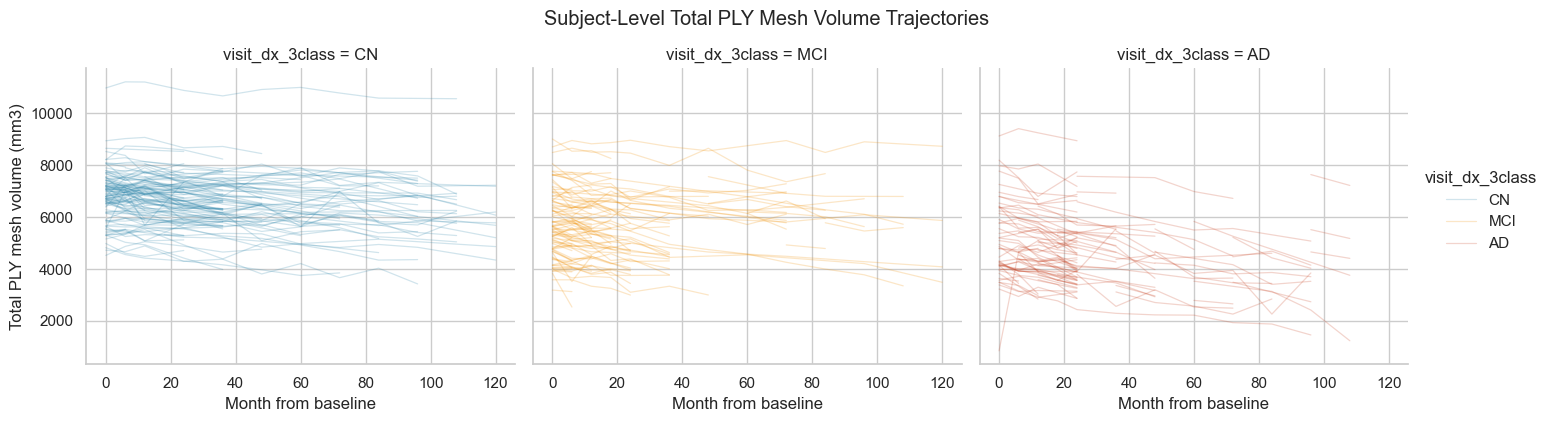

In [12]:
if "total_mesh_volume_mm3" in merged.columns:
    mesh_spaghetti = sample_subjects(merged.dropna(subset=["total_mesh_volume_mm3"]), max_per_group=120)
    if not mesh_spaghetti.empty:
        grid = sns.relplot(
            data=mesh_spaghetti,
            x="month_from_viscode",
            y="total_mesh_volume_mm3",
            col="visit_dx_3class",
            col_order=DX_ORDER,
            hue="visit_dx_3class",
            hue_order=DX_ORDER,
            units="RID",
            estimator=None,
            kind="line",
            palette=DX_PALETTE,
            alpha=0.22,
            linewidth=0.9,
            height=4,
            aspect=1.2,
        )
        grid.set_axis_labels("Month from baseline", "Total PLY mesh volume (mm3)")
        grid.fig.suptitle("Subject-Level Total PLY Mesh Volume Trajectories", y=1.05)
        grid.fig.savefig(PLOTS_DIR / "mesh_subject_spaghetti_by_diagnosis.png", dpi=180, bbox_inches="tight")
        plt.show()
    else:
        print("No mesh trajectory data available.")
else:
    print("No total_mesh_volume_mm3 column available.")

## Baseline-Normalized Change

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/06_baseline_normalized_change.png


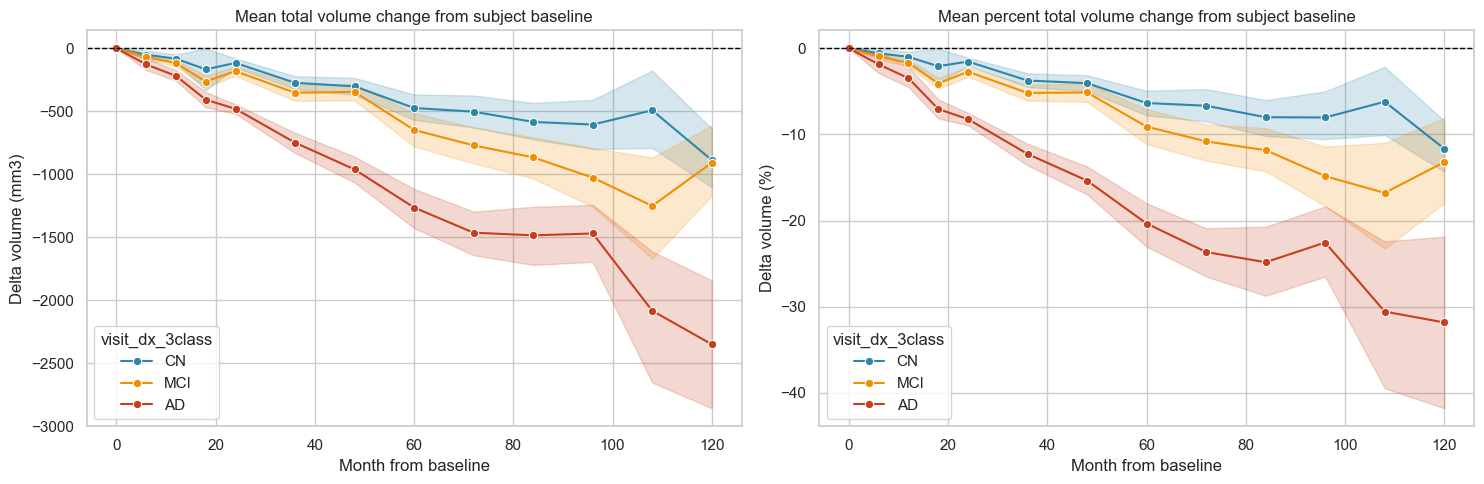

,RID,VISCODE,visit_dx_3class,subject_conversion_type,total_mask_volume_mm3,total_delta_mm3,total_delta_pct
0,10,bl,AD,stable_AD,5493.0,0.0,0.000000
1,10,m06,AD,stable_AD,5443.0,-50.0,-0.910249
2,10,m12,AD,stable_AD,5486.0,-7.0,-0.127435
3,10,m24,AD,stable_AD,5010.0,-483.0,-8.793009
4,1001,bl,AD,stable_AD,5950.0,0.0,0.000000


In [13]:
base_values = (
    merged.sort_values(["RID", "month_from_viscode"])
    .groupby("RID", as_index=False)
    .first()[["RID", "total_mask_volume_mm3", "left_mask_volume_mm3", "right_mask_volume_mm3"]]
    .rename(
        columns={
            "total_mask_volume_mm3": "baseline_total_mask_volume_mm3",
            "left_mask_volume_mm3": "baseline_left_mask_volume_mm3",
            "right_mask_volume_mm3": "baseline_right_mask_volume_mm3",
        }
    )
)
change = merged.merge(base_values, on="RID", how="left")
for side in ["total", "left", "right"]:
    cur = f"{side}_mask_volume_mm3"
    base = f"baseline_{side}_mask_volume_mm3"
    if cur in change.columns and base in change.columns:
        change[f"{side}_delta_mm3"] = change[cur] - change[base]
        change[f"{side}_delta_pct"] = 100.0 * change[f"{side}_delta_mm3"] / change[base].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(
    data=change,
    x="month_from_viscode",
    y="total_delta_mm3",
    hue="visit_dx_3class",
    hue_order=DX_ORDER,
    palette=DX_PALETTE,
    estimator="mean",
    errorbar=("ci", 95),
    marker="o",
    ax=axes[0],
)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Mean total volume change from subject baseline")
axes[0].set_xlabel("Month from baseline")
axes[0].set_ylabel("Delta volume (mm3)")

sns.lineplot(
    data=change,
    x="month_from_viscode",
    y="total_delta_pct",
    hue="visit_dx_3class",
    hue_order=DX_ORDER,
    palette=DX_PALETTE,
    estimator="mean",
    errorbar=("ci", 95),
    marker="o",
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Mean percent total volume change from subject baseline")
axes[1].set_xlabel("Month from baseline")
axes[1].set_ylabel("Delta volume (%)")
savefig("06_baseline_normalized_change")
plt.show()

display(change[["RID", "VISCODE", "visit_dx_3class", "subject_conversion_type", "total_mask_volume_mm3", "total_delta_mm3", "total_delta_pct"]].head())

## Mesh PLY Baseline-Normalized Change

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/07_mesh_baseline_normalized_change.png


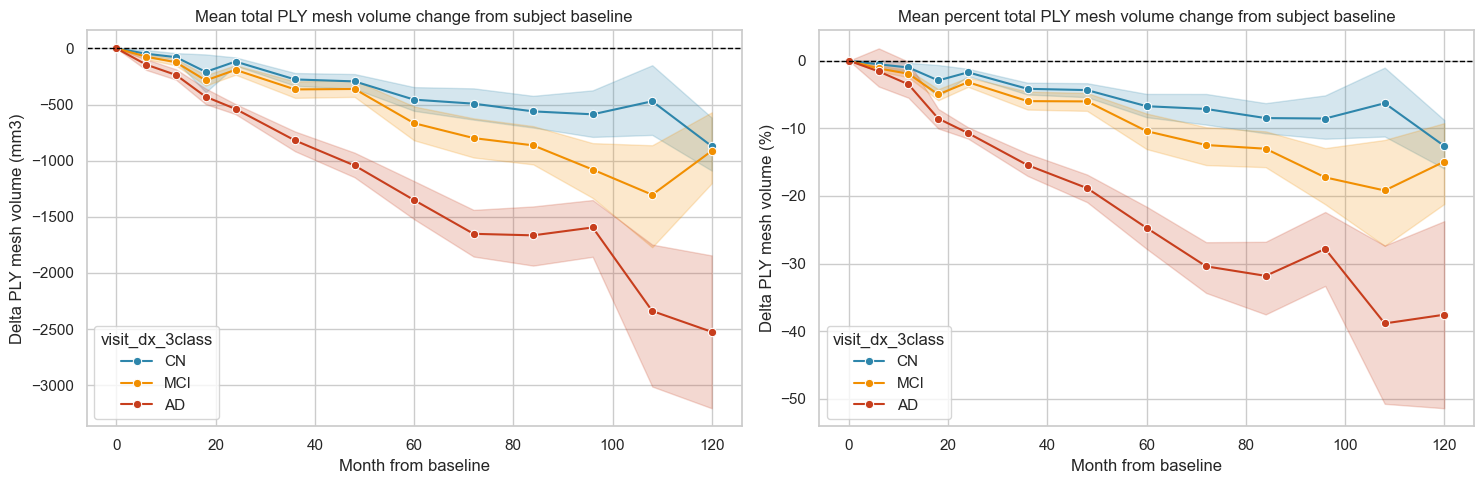

,RID,VISCODE,visit_dx_3class,subject_conversion_type,total_mesh_volume_mm3,total_mesh_delta_mm3,total_mesh_delta_pct
0,10,bl,AD,stable_AD,4785.277155,0.000000,0.000000
1,10,m06,AD,stable_AD,4736.414684,-48.862471,-1.021100
2,10,m12,AD,stable_AD,4763.787571,-21.489584,-0.449077
3,10,m24,AD,stable_AD,4240.211218,-545.065937,-11.390478
4,1001,bl,AD,stable_AD,5137.205372,0.000000,0.000000


In [14]:
if {"total_mesh_volume_mm3", "left_mesh_volume_mm3", "right_mesh_volume_mm3"}.issubset(merged.columns):
    mesh_base_values = (
        merged.sort_values(["RID", "month_from_viscode"])
        .groupby("RID", as_index=False)
        .first()[["RID", "total_mesh_volume_mm3", "left_mesh_volume_mm3", "right_mesh_volume_mm3"]]
        .rename(
            columns={
                "total_mesh_volume_mm3": "baseline_total_mesh_volume_mm3",
                "left_mesh_volume_mm3": "baseline_left_mesh_volume_mm3",
                "right_mesh_volume_mm3": "baseline_right_mesh_volume_mm3",
            }
        )
    )
    mesh_change = merged.merge(mesh_base_values, on="RID", how="left")
    for side in ["total", "left", "right"]:
        cur = f"{side}_mesh_volume_mm3"
        base = f"baseline_{side}_mesh_volume_mm3"
        mesh_change[f"{side}_mesh_delta_mm3"] = mesh_change[cur] - mesh_change[base]
        mesh_change[f"{side}_mesh_delta_pct"] = 100.0 * mesh_change[f"{side}_mesh_delta_mm3"] / mesh_change[base].replace(0, np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.lineplot(
        data=mesh_change,
        x="month_from_viscode",
        y="total_mesh_delta_mm3",
        hue="visit_dx_3class",
        hue_order=DX_ORDER,
        palette=DX_PALETTE,
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        ax=axes[0],
    )
    axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[0].set_title("Mean total PLY mesh volume change from subject baseline")
    axes[0].set_xlabel("Month from baseline")
    axes[0].set_ylabel("Delta PLY mesh volume (mm3)")

    sns.lineplot(
        data=mesh_change,
        x="month_from_viscode",
        y="total_mesh_delta_pct",
        hue="visit_dx_3class",
        hue_order=DX_ORDER,
        palette=DX_PALETTE,
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        ax=axes[1],
    )
    axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[1].set_title("Mean percent total PLY mesh volume change from subject baseline")
    axes[1].set_xlabel("Month from baseline")
    axes[1].set_ylabel("Delta PLY mesh volume (%)")
    savefig("07_mesh_baseline_normalized_change")
    plt.show()

    display(mesh_change[["RID", "VISCODE", "visit_dx_3class", "subject_conversion_type", "total_mesh_volume_mm3", "total_mesh_delta_mm3", "total_mesh_delta_pct"]].head())
else:
    print("Mesh volume columns are not available.")

## Annualized Atrophy Rates

,RID,first_dx,last_dx,subject_conversion_type,first_month,last_month,baseline_total_mask_volume_mm3,last_total_mask_volume_mm3,annualized_change_mm3,annualized_change_pct
0,10,AD,AD,stable_AD,0.0,24.0,5493.0,5010.0,-241.500000,-4.396505
1,1001,AD,AD,stable_AD,0.0,12.0,5950.0,5461.0,-489.000000,-8.218487
2,1002,CN,CN,stable_CN,0.0,36.0,7501.0,7063.0,-146.000000,-1.946407
3,1004,MCI,AD,MCI_to_AD,0.0,84.0,6523.0,4569.0,-279.142857,-4.279363
4,1007,MCI,AD,MCI_to_AD,0.0,60.0,5256.0,4535.0,-144.200000,-2.743531


/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/07_annualized_atrophy_rates.png


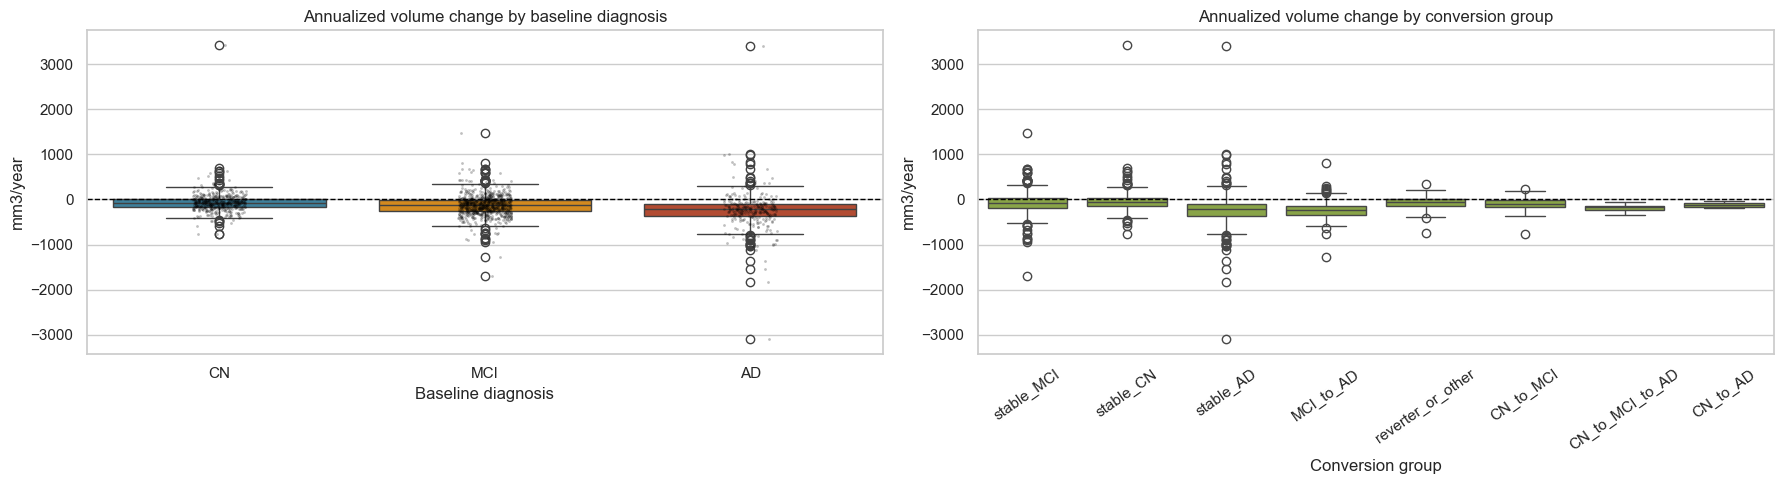

In [15]:
def annualized_change_table(df):
    rows = []
    for rid, group in df.dropna(subset=["total_mask_volume_mm3"]).groupby("RID", sort=False):
        group = group.sort_values(["month_from_viscode", "VISCODE"])
        if len(group) < 2:
            continue
        first = group.iloc[0]
        last = group.iloc[-1]
        months = last["month_from_viscode"] - first["month_from_viscode"]
        if not np.isfinite(months) or months <= 0:
            continue
        rows.append(
            {
                "RID": rid,
                "first_dx": first["visit_dx_3class"],
                "last_dx": last["visit_dx_3class"],
                "subject_conversion_type": first.get("subject_conversion_type", ""),
                "first_month": first["month_from_viscode"],
                "last_month": last["month_from_viscode"],
                "baseline_total_mask_volume_mm3": first["total_mask_volume_mm3"],
                "last_total_mask_volume_mm3": last["total_mask_volume_mm3"],
                "annualized_change_mm3": (last["total_mask_volume_mm3"] - first["total_mask_volume_mm3"]) / (months / 12.0),
                "annualized_change_pct": 100.0 * (last["total_mask_volume_mm3"] - first["total_mask_volume_mm3"]) / first["total_mask_volume_mm3"] / (months / 12.0),
            }
        )
    return pd.DataFrame(rows)

atrophy = annualized_change_table(merged)
display(atrophy.head())
atrophy.to_csv(OUT_DIR / "notebook_annualized_atrophy_rates.csv", index=False)

if not atrophy.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    sns.boxplot(data=atrophy, x="first_dx", y="annualized_change_mm3", order=DX_ORDER, palette=DX_PALETTE, hue="first_dx", legend=False, ax=axes[0])
    sns.stripplot(data=atrophy, x="first_dx", y="annualized_change_mm3", order=DX_ORDER, color="black", alpha=0.25, size=2, ax=axes[0])
    axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[0].set_title("Annualized volume change by baseline diagnosis")
    axes[0].set_xlabel("Baseline diagnosis")
    axes[0].set_ylabel("mm3/year")

    order = atrophy["subject_conversion_type"].value_counts().index
    sns.boxplot(data=atrophy, x="subject_conversion_type", y="annualized_change_mm3", order=order, color="#8FB339", ax=axes[1])
    axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].set_title("Annualized volume change by conversion group")
    axes[1].set_xlabel("Conversion group")
    axes[1].set_ylabel("mm3/year")
    savefig("07_annualized_atrophy_rates")
    plt.show()

## Mesh PLY Annualized Volume Change

,RID,first_dx,last_dx,subject_conversion_type,first_month,last_month,baseline_total_mesh_volume_mm3,last_total_mesh_volume_mm3,annualized_mesh_change_mm3,annualized_mesh_change_pct
0,10,AD,AD,stable_AD,0.0,24.0,4785.277155,4240.211218,-272.532969,-5.695239
1,1001,AD,AD,stable_AD,0.0,12.0,5137.205372,4643.269228,-493.936145,-9.614880
2,1002,CN,CN,stable_CN,0.0,36.0,6820.426164,6355.280171,-155.048665,-2.273299
3,1004,MCI,AD,MCI_to_AD,0.0,84.0,5762.131641,3623.108311,-305.574761,-5.303155
4,1007,MCI,AD,MCI_to_AD,0.0,60.0,4502.019215,3787.395984,-142.924646,-3.174679


/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/08_mesh_annualized_atrophy_rates.png


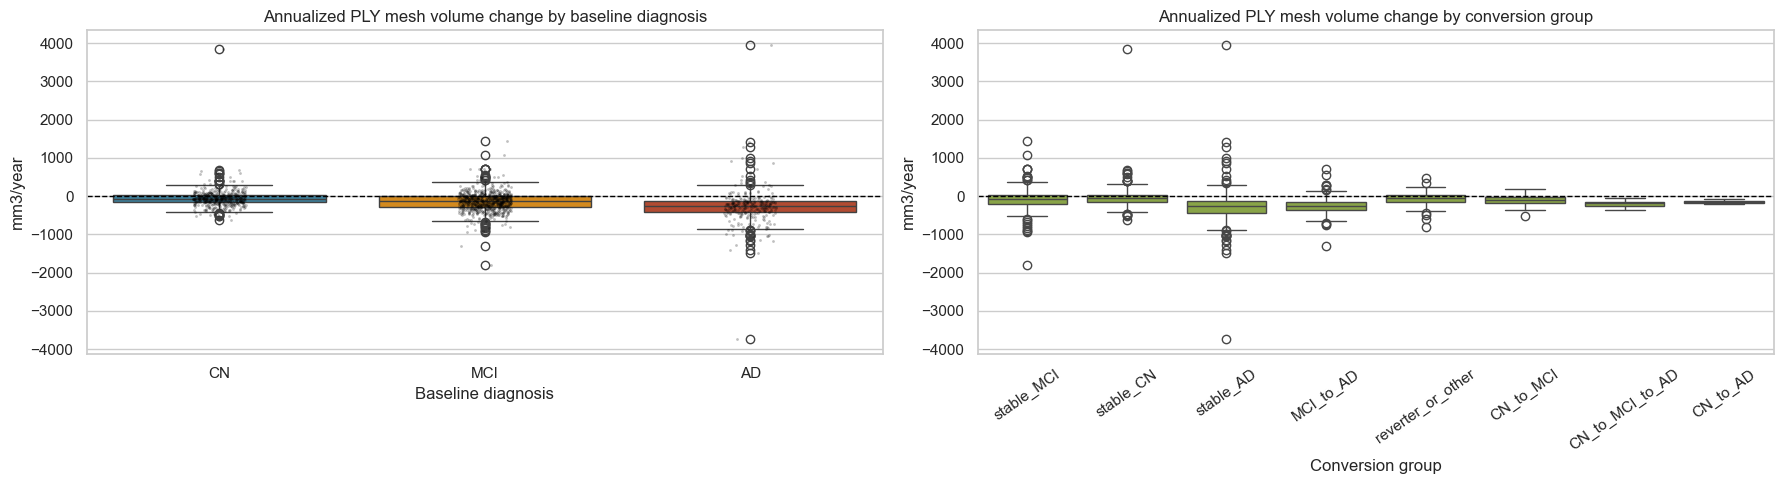

In [16]:
def annualized_mesh_change_table(df):
    if "total_mesh_volume_mm3" not in df.columns:
        return pd.DataFrame()
    rows = []
    for rid, group in df.dropna(subset=["total_mesh_volume_mm3"]).groupby("RID", sort=False):
        group = group.sort_values(["month_from_viscode", "VISCODE"])
        if len(group) < 2:
            continue
        first = group.iloc[0]
        last = group.iloc[-1]
        months = last["month_from_viscode"] - first["month_from_viscode"]
        if not np.isfinite(months) or months <= 0:
            continue
        rows.append(
            {
                "RID": rid,
                "first_dx": first["visit_dx_3class"],
                "last_dx": last["visit_dx_3class"],
                "subject_conversion_type": first.get("subject_conversion_type", ""),
                "first_month": first["month_from_viscode"],
                "last_month": last["month_from_viscode"],
                "baseline_total_mesh_volume_mm3": first["total_mesh_volume_mm3"],
                "last_total_mesh_volume_mm3": last["total_mesh_volume_mm3"],
                "annualized_mesh_change_mm3": (last["total_mesh_volume_mm3"] - first["total_mesh_volume_mm3"]) / (months / 12.0),
                "annualized_mesh_change_pct": 100.0 * (last["total_mesh_volume_mm3"] - first["total_mesh_volume_mm3"]) / first["total_mesh_volume_mm3"] / (months / 12.0),
            }
        )
    return pd.DataFrame(rows)

mesh_atrophy = annualized_mesh_change_table(merged)
display(mesh_atrophy.head())
mesh_atrophy.to_csv(OUT_DIR / "notebook_mesh_annualized_atrophy_rates.csv", index=False)

if not mesh_atrophy.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    sns.boxplot(data=mesh_atrophy, x="first_dx", y="annualized_mesh_change_mm3", order=DX_ORDER, palette=DX_PALETTE, hue="first_dx", legend=False, ax=axes[0])
    sns.stripplot(data=mesh_atrophy, x="first_dx", y="annualized_mesh_change_mm3", order=DX_ORDER, color="black", alpha=0.25, size=2, ax=axes[0])
    axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[0].set_title("Annualized PLY mesh volume change by baseline diagnosis")
    axes[0].set_xlabel("Baseline diagnosis")
    axes[0].set_ylabel("mm3/year")

    order = mesh_atrophy["subject_conversion_type"].value_counts().index
    sns.boxplot(data=mesh_atrophy, x="subject_conversion_type", y="annualized_mesh_change_mm3", order=order, color="#8FB339", ax=axes[1])
    axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].set_title("Annualized PLY mesh volume change by conversion group")
    axes[1].set_xlabel("Conversion group")
    axes[1].set_ylabel("mm3/year")
    savefig("08_mesh_annualized_atrophy_rates")
    plt.show()
else:
    print("No mesh annualized atrophy rows available yet.")

## Conversion-Aligned Trends

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/08_conversion_aligned_trends.png


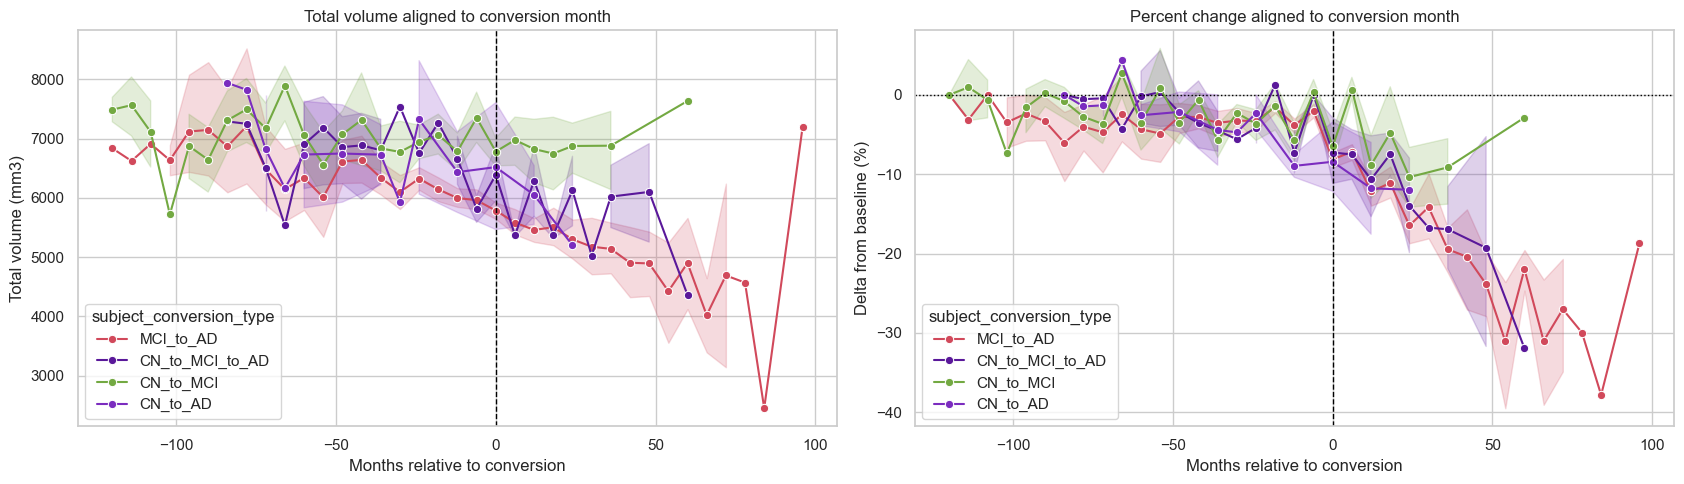

In [17]:
aligned = merged[
    merged["subject_conversion_type"].isin(["CN_to_MCI", "CN_to_AD", "CN_to_MCI_to_AD", "MCI_to_AD"])
    & merged["conversion_month"].notna()
].copy()

if not aligned.empty:
    aligned["month_relative_to_conversion"] = aligned["month_from_viscode"] - aligned["conversion_month"]
    fig, axes = plt.subplots(1, 2, figsize=(17, 5))
    sns.lineplot(
        data=aligned,
        x="month_relative_to_conversion",
        y="total_mask_volume_mm3",
        hue="subject_conversion_type",
        palette=CONVERSION_PALETTE,
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        ax=axes[0],
    )
    axes[0].axvline(0, color="black", linewidth=1, linestyle="--")
    axes[0].set_title("Total volume aligned to conversion month")
    axes[0].set_xlabel("Months relative to conversion")
    axes[0].set_ylabel("Total volume (mm3)")

    aligned_change = aligned.merge(base_values[["RID", "baseline_total_mask_volume_mm3"]], on="RID", how="left")
    aligned_change["total_delta_pct"] = 100.0 * (
        aligned_change["total_mask_volume_mm3"] - aligned_change["baseline_total_mask_volume_mm3"]
    ) / aligned_change["baseline_total_mask_volume_mm3"].replace(0, np.nan)
    sns.lineplot(
        data=aligned_change,
        x="month_relative_to_conversion",
        y="total_delta_pct",
        hue="subject_conversion_type",
        palette=CONVERSION_PALETTE,
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        ax=axes[1],
    )
    axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
    axes[1].axhline(0, color="black", linewidth=1, linestyle=":")
    axes[1].set_title("Percent change aligned to conversion month")
    axes[1].set_xlabel("Months relative to conversion")
    axes[1].set_ylabel("Delta from baseline (%)")
    savefig("08_conversion_aligned_trends")
    plt.show()
else:
    print("No conversion-aligned rows available yet. This is expected during a small dry run.")

## Left-Right Asymmetry

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/09_left_right_asymmetry.png


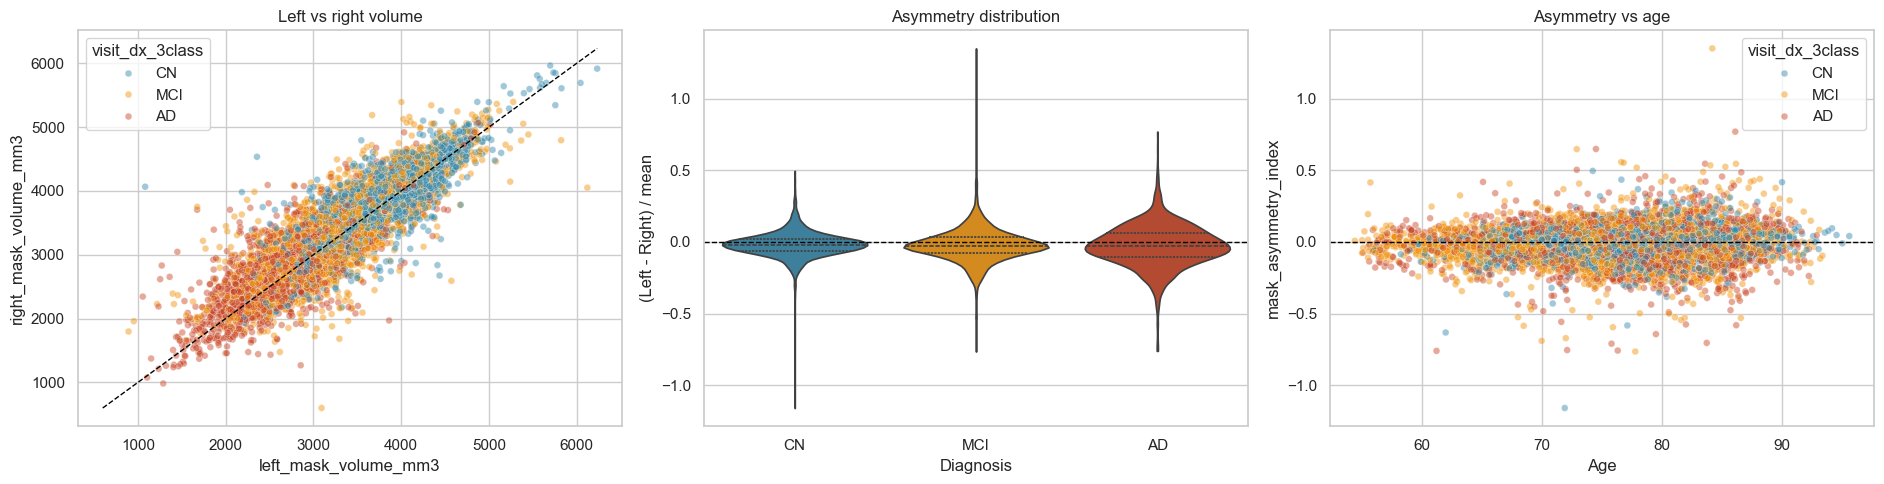

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

if {"left_mask_volume_mm3", "right_mask_volume_mm3"}.issubset(merged.columns):
    sns.scatterplot(
        data=merged,
        x="left_mask_volume_mm3",
        y="right_mask_volume_mm3",
        hue="visit_dx_3class",
        hue_order=DX_ORDER,
        palette=DX_PALETTE,
        alpha=0.45,
        s=24,
        ax=axes[0],
    )
    low = np.nanmin(merged[["left_mask_volume_mm3", "right_mask_volume_mm3"]].values)
    high = np.nanmax(merged[["left_mask_volume_mm3", "right_mask_volume_mm3"]].values)
    axes[0].plot([low, high], [low, high], color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Left vs right volume")

if "mask_asymmetry_index" in merged.columns:
    sns.violinplot(
        data=merged,
        x="visit_dx_3class",
        y="mask_asymmetry_index",
        order=DX_ORDER,
        palette=DX_PALETTE,
        hue="visit_dx_3class",
        legend=False,
        inner="quartile",
        cut=0,
        ax=axes[1],
    )
    axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[1].set_title("Asymmetry distribution")
    axes[1].set_xlabel("Diagnosis")
    axes[1].set_ylabel("(Left - Right) / mean")

    sns.scatterplot(
        data=merged,
        x="AGE",
        y="mask_asymmetry_index",
        hue="visit_dx_3class",
        hue_order=DX_ORDER,
        palette=DX_PALETTE,
        alpha=0.45,
        s=24,
        ax=axes[2],
    )
    axes[2].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[2].set_title("Asymmetry vs age")
    axes[2].set_xlabel("Age")
savefig("09_left_right_asymmetry")
plt.show()

## Cognitive Associations

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/10_cognitive_associations_total_volume.png


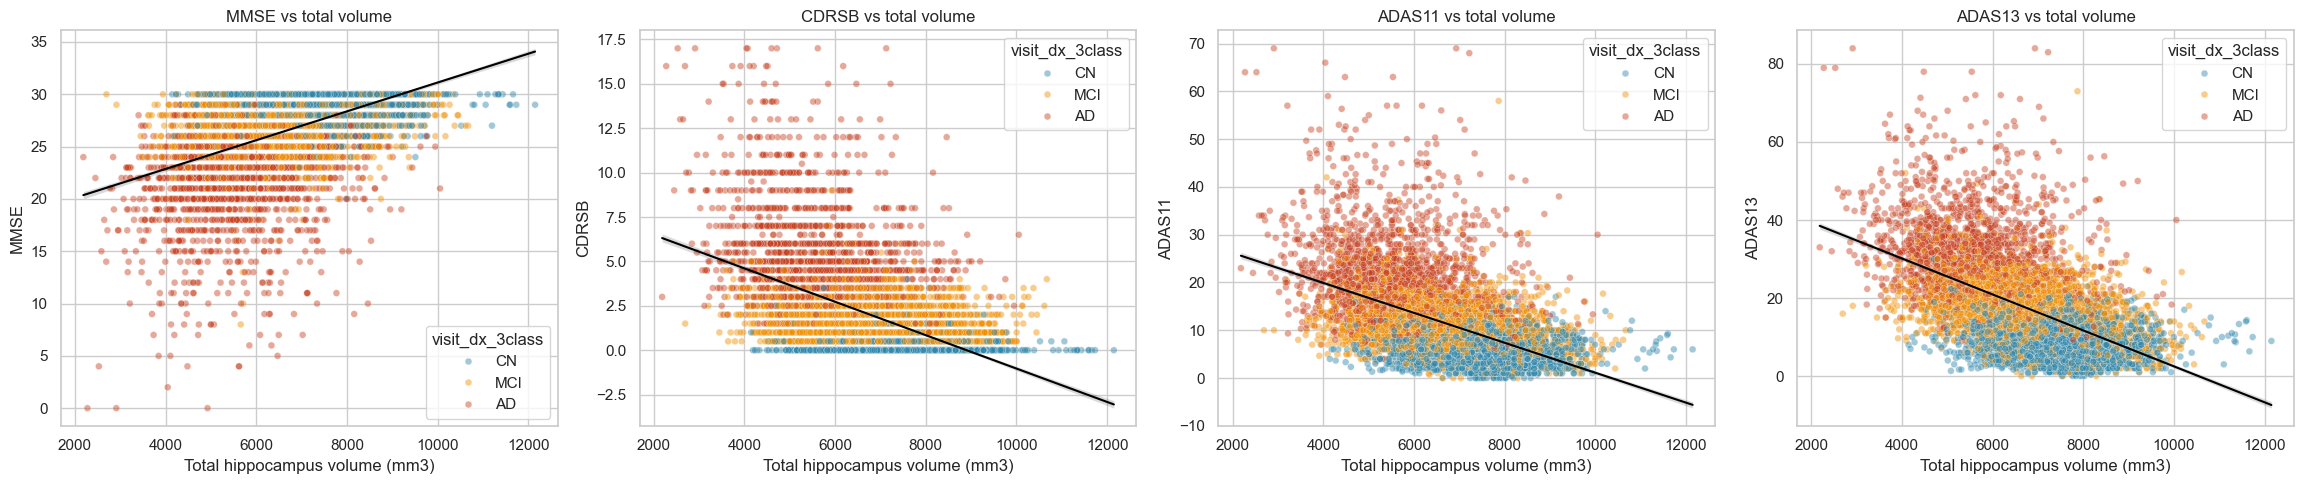

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/11_cognitive_associations_total_mesh_volume.png


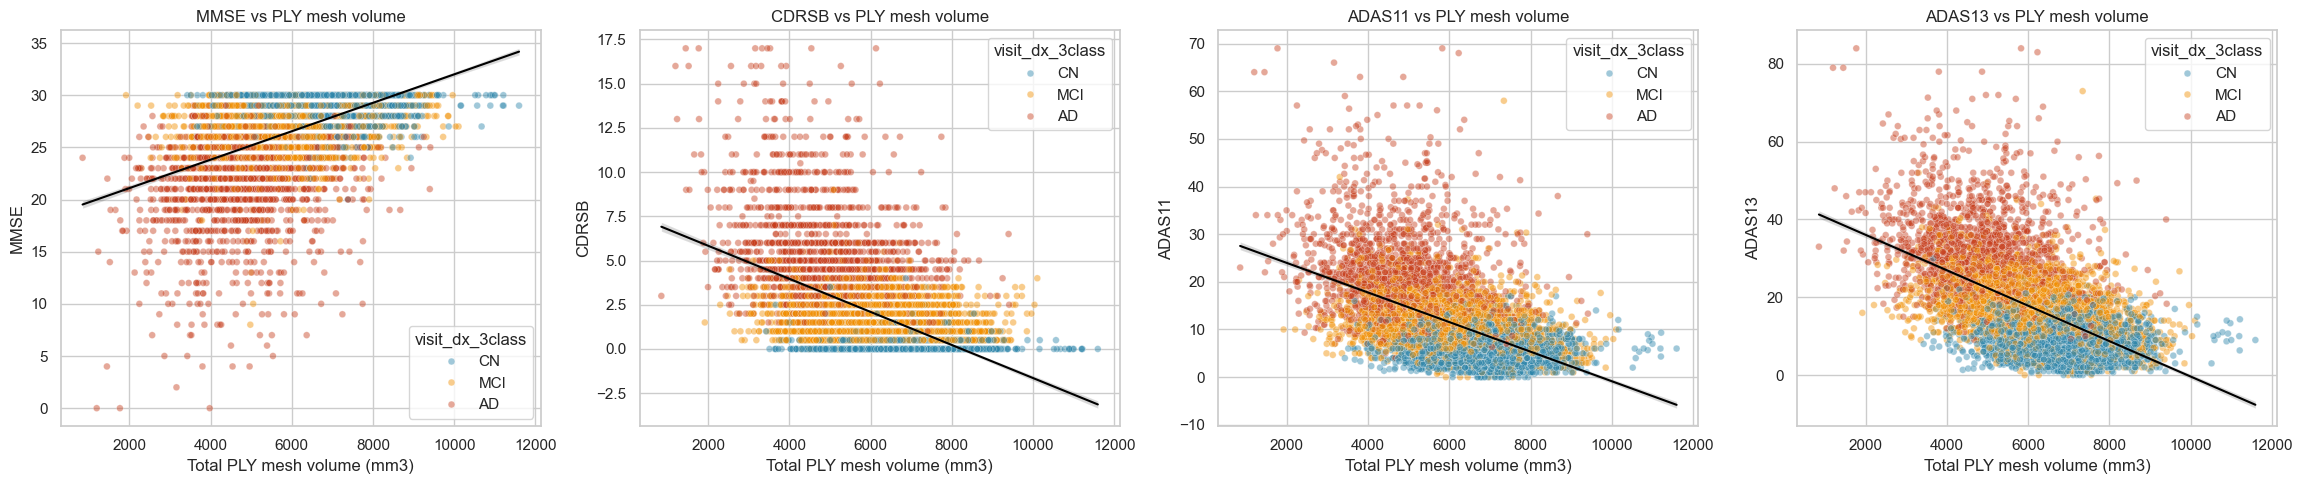

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/11_spearman_correlation_matrix.png


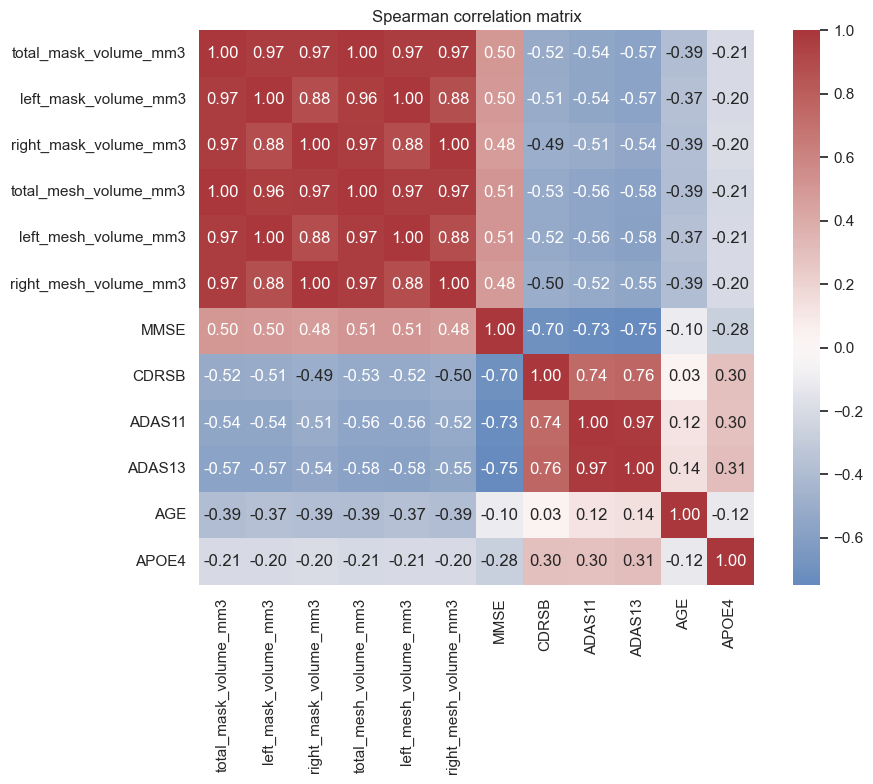

In [19]:
cognitive_cols = [col for col in ["MMSE", "CDRSB", "ADAS11", "ADAS13"] if col in merged.columns]
if cognitive_cols:
    fig, axes = plt.subplots(1, len(cognitive_cols), figsize=(5.8 * len(cognitive_cols), 5), squeeze=False)
    for ax, col in zip(axes.ravel(), cognitive_cols):
        sns.scatterplot(
            data=merged,
            x="total_mask_volume_mm3",
            y=col,
            hue="visit_dx_3class",
            hue_order=DX_ORDER,
            palette=DX_PALETTE,
            alpha=0.45,
            s=24,
            ax=ax,
        )
        sns.regplot(
            data=merged,
            x="total_mask_volume_mm3",
            y=col,
            scatter=False,
            color="black",
            line_kws={"linewidth": 1.5},
            ax=ax,
        )
        ax.set_title(f"{col} vs total volume")
        ax.set_xlabel("Total hippocampus volume (mm3)")
    savefig("10_cognitive_associations_total_volume")
    plt.show()

    if "total_mesh_volume_mm3" in merged.columns:
        fig, axes = plt.subplots(1, len(cognitive_cols), figsize=(5.8 * len(cognitive_cols), 5), squeeze=False)
        for ax, col in zip(axes.ravel(), cognitive_cols):
            sns.scatterplot(
                data=merged,
                x="total_mesh_volume_mm3",
                y=col,
                hue="visit_dx_3class",
                hue_order=DX_ORDER,
                palette=DX_PALETTE,
                alpha=0.45,
                s=24,
                ax=ax,
            )
            sns.regplot(
                data=merged,
                x="total_mesh_volume_mm3",
                y=col,
                scatter=False,
                color="black",
                line_kws={"linewidth": 1.5},
                ax=ax,
            )
            ax.set_title(f"{col} vs PLY mesh volume")
            ax.set_xlabel("Total PLY mesh volume (mm3)")
        savefig("11_cognitive_associations_total_mesh_volume")
        plt.show()

    corr_cols = [
        "total_mask_volume_mm3",
        "left_mask_volume_mm3",
        "right_mask_volume_mm3",
        "total_mesh_volume_mm3",
        "left_mesh_volume_mm3",
        "right_mesh_volume_mm3",
    ] + cognitive_cols + ["AGE", "APOE4"]
    corr_cols = [col for col in corr_cols if col in merged.columns]
    corr = merged[corr_cols].corr(numeric_only=True, method="spearman")
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax)
    ax.set_title("Spearman correlation matrix")
    savefig("11_spearman_correlation_matrix")
    plt.show()
else:
    print("No cognitive columns found.")

## Mesh and Reconstruction QC

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/12_mesh_reconstruction_qc.png


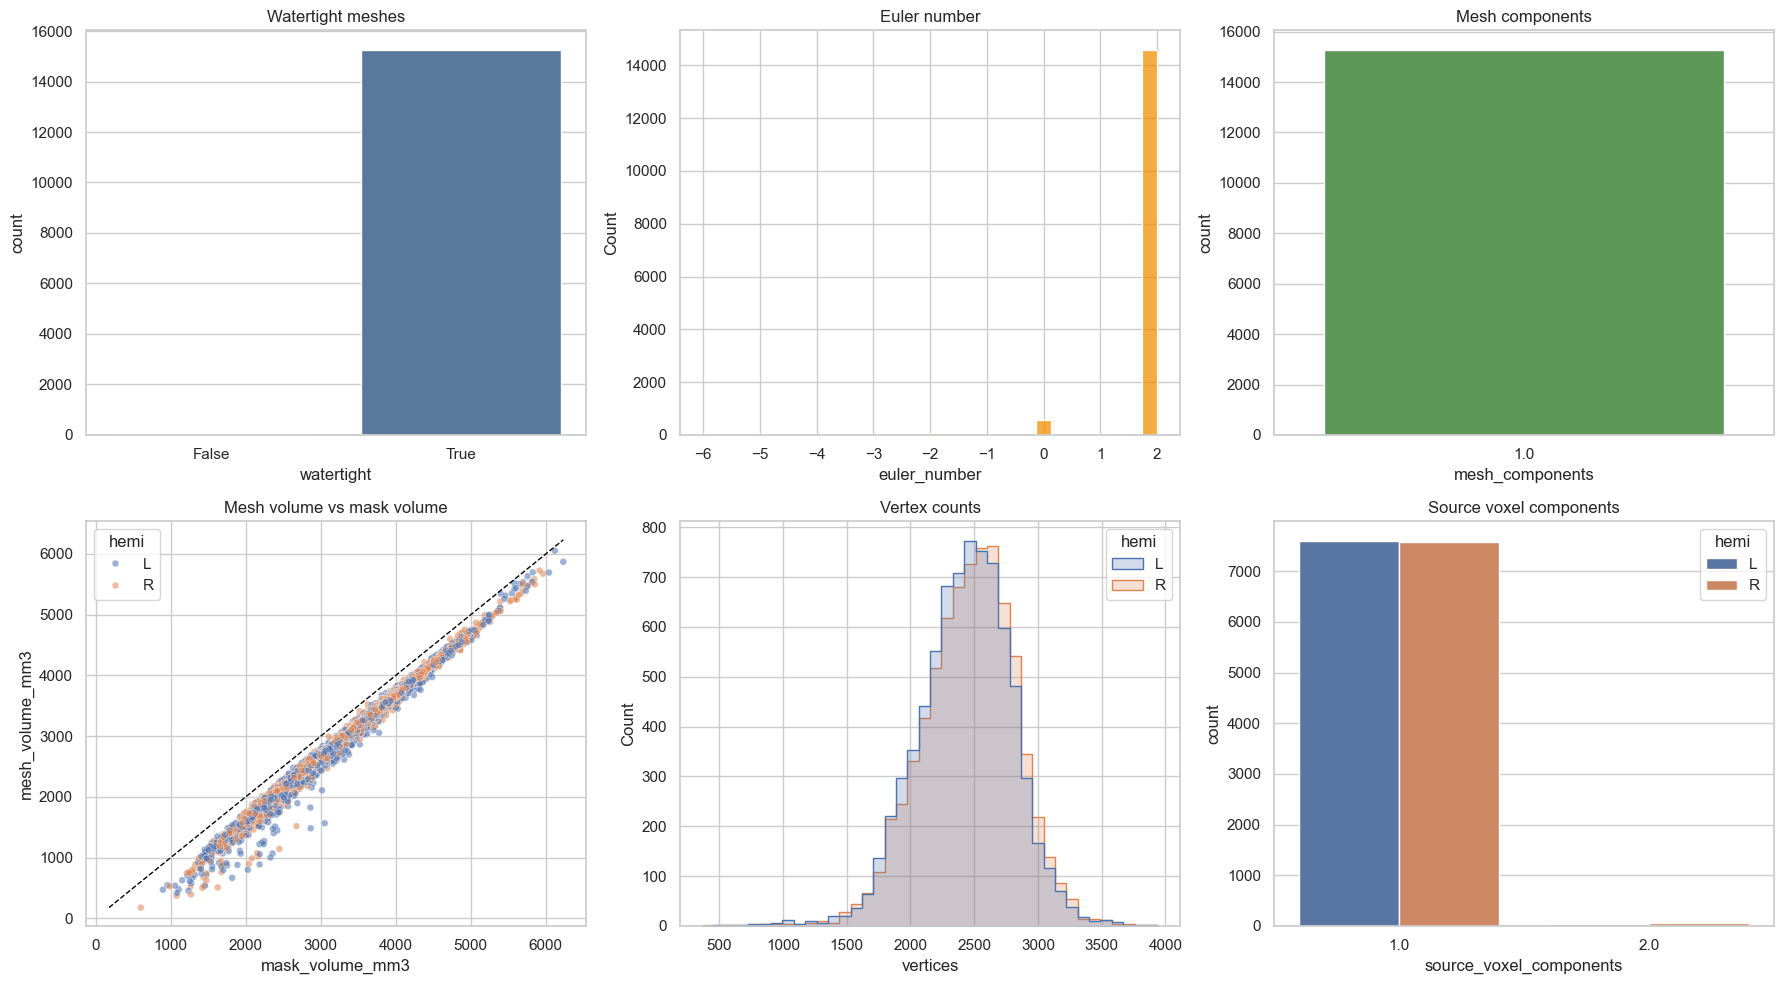

QC flagged rows: 55


,RID,VISCODE,month_from_viscode,hemi,mask_path,ply_path,sigma,closing_iterations,padding,status,error,voxel_size_x_mm,voxel_size_y_mm,voxel_size_z_mm,voxel_volume_mm3,mask_voxels,mask_volume_mm3,vertices,triangles,surface_area_mm2,mesh_volume_mm3,watertight,euler_number,mesh_components,source_voxel_components,source_component_sizes,repaired_voxel_components,repaired_component_sizes,crop_x0,crop_y0,crop_z0,crop_x1,crop_y1,crop_z1,traceback
0,10,bl,0,L,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_m...,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_p...,1.2,1,8,skipped_existing,NaN,1.0,1.0,1.0,1.0,2984.0,2984.0,2168.0,4332.0,1443.998884,2636.561766,True,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10,bl,0,R,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_m...,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_p...,1.2,1,8,skipped_existing,NaN,1.0,1.0,1.0,1.0,2509.0,2509.0,1880.0,3756.0,1281.492167,2148.715389,True,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,m06,6,L,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_m...,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_p...,1.2,1,8,skipped_existing,NaN,1.0,1.0,1.0,1.0,2844.0,2844.0,2072.0,4140.0,1366.245480,2492.602276,True,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10,m06,6,R,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_m...,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_p...,1.2,1,8,skipped_existing,NaN,1.0,1.0,1.0,1.0,2599.0,2599.0,1986.0,3968.0,1313.913221,2243.812408,True,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10,m12,12,L,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_m...,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_p...,1.2,1,8,skipped_existing,NaN,1.0,1.0,1.0,1.0,2943.0,2943.0,2144.0,4284.0,1409.049573,2578.931666,True,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10,m12,12,R,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_m...,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_p...,1.2,1,8,skipped_existing,NaN,1.0,1.0,1.0,1.0,2543.0,2543.0,2048.0,4092.0,1340.843324,2184.855904,True,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,10,m24,24,L,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_m...,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_p...,1.2,1,8,skipped_existing,NaN,1.0,1.0,1.0,1.0,2741.0,2741.0,2006.0,4008.0,1328.945271,2387.076304,True,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,10,m24,24,R,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_m...,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_p...,1.2,1,8,skipped_existing,NaN,1.0,1.0,1.0,1.0,2269.0,2269.0,1804.0,3604.0,1180.384487,1853.134914,True,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1001,bl,0,L,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_m...,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_p...,1.2,1,8,skipped_existing,NaN,1.0,1.0,1.0,1.0,3142.0,3142.0,2370.0,4736.0,1576.565743,2680.241012,True,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1001,bl,0,R,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_m...,/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_p...,1.2,1,8,skipped_existing,NaN,1.0,1.0,1.0,1.0,2808.0,2808.0,2074.0,4144.0,1383.253767,2456.964361,True,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
qc = vol_long.copy()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

if "watertight" in qc.columns:
    sns.countplot(data=qc, x="watertight", color="#4C78A8", ax=axes[0, 0])
    axes[0, 0].set_title("Watertight meshes")

if "euler_number" in qc.columns:
    sns.histplot(data=qc, x="euler_number", bins=30, color="#F18F01", ax=axes[0, 1])
    axes[0, 1].set_title("Euler number")

if "mesh_components" in qc.columns:
    sns.countplot(data=qc, x="mesh_components", color="#54A24B", ax=axes[0, 2])
    axes[0, 2].set_title("Mesh components")

if {"mask_volume_mm3", "mesh_volume_mm3"}.issubset(qc.columns):
    sns.scatterplot(data=qc, x="mask_volume_mm3", y="mesh_volume_mm3", hue="hemi", alpha=0.55, s=24, ax=axes[1, 0])
    axes[1, 0].set_title("Mesh volume vs mask volume")
    low = np.nanmin(qc[["mask_volume_mm3", "mesh_volume_mm3"]].values)
    high = np.nanmax(qc[["mask_volume_mm3", "mesh_volume_mm3"]].values)
    axes[1, 0].plot([low, high], [low, high], color="black", linestyle="--", linewidth=1)

if "vertices" in qc.columns:
    sns.histplot(data=qc, x="vertices", hue="hemi", bins=40, element="step", ax=axes[1, 1])
    axes[1, 1].set_title("Vertex counts")

if "source_voxel_components" in qc.columns:
    sns.countplot(data=qc, x="source_voxel_components", hue="hemi", ax=axes[1, 2])
    axes[1, 2].set_title("Source voxel components")

savefig("12_mesh_reconstruction_qc")
plt.show()

qc_flags = qc[
    (qc.get("status", "ok") != "ok")
    | (qc.get("watertight", True) != True)
    | (qc.get("mesh_components", 1) != 1)
].copy()
print(f"QC flagged rows: {len(qc_flags)}")
display(qc_flags.head(30))

## Missingness and Visit Coverage

/home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots/13_visit_coverage_heatmap.png


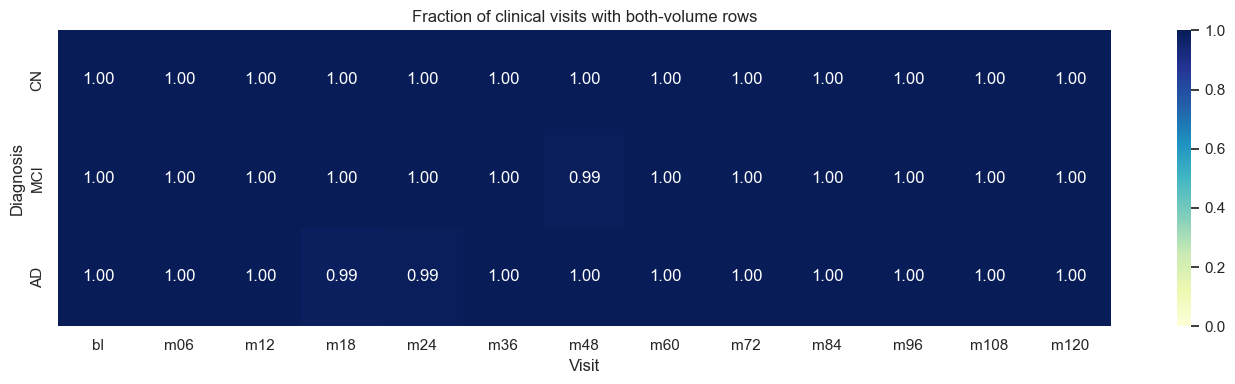

VISCODE,bl,m06,m12,m18,m24,m36,m48,m60,m72,m84,m96,m108,m120
visit_dx_3class,,,,,,,,,,,,,
CN,523,405,410,10,408,173,182,85,79,58,35,20,11
MCI,863,739,650,205,445,192,178,63,63,47,28,12,8
AD,338,312,344,84,301,110,105,52,44,27,23,11,2


In [21]:
visit_order = sorted(clinical["VISCODE"].dropna().unique(), key=month_from_viscode)

coverage = (
    clinical.assign(has_volume=clinical[["RID", "VISCODE"]].apply(tuple, axis=1).isin(set(merged[["RID", "VISCODE"]].apply(tuple, axis=1))))
    .pivot_table(index="visit_dx_3class", columns="VISCODE", values="has_volume", aggfunc="mean")
    .reindex(index=DX_ORDER, columns=visit_order)
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(coverage, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax)
ax.set_title("Fraction of clinical visits with both-volume rows")
ax.set_xlabel("Visit")
ax.set_ylabel("Diagnosis")
savefig("13_visit_coverage_heatmap")
plt.show()

counts = merged.pivot_table(index="visit_dx_3class", columns="VISCODE", values="RID", aggfunc="count").reindex(index=DX_ORDER, columns=visit_order)
display(counts.fillna(0).astype(int))

## Optional Statistical Models

In [22]:
if smf is None:
    print("statsmodels is unavailable.")
elif len(merged) < 30:
    print("Too few merged rows for meaningful models. Re-run after full processing finishes.")
else:
    model_df = merged.dropna(subset=["total_mask_volume_mm3", "AGE", "visit_dx_3class", "PTGENDER"]).copy()
    model_df["visit_dx_3class"] = pd.Categorical(model_df["visit_dx_3class"], categories=DX_ORDER)
    print(f"Model rows: {len(model_df)}, subjects: {model_df['RID'].nunique()}")

    ols = smf.ols("total_mask_volume_mm3 ~ AGE + C(PTGENDER) + C(visit_dx_3class)", data=model_df).fit()
    print("OLS: total volume ~ age + sex + diagnosis")
    display(ols.summary().tables[1])

    if "total_mesh_volume_mm3" in model_df.columns:
        mesh_model_df = model_df.dropna(subset=["total_mesh_volume_mm3"]).copy()
        mesh_ols = smf.ols("total_mesh_volume_mm3 ~ AGE + C(PTGENDER) + C(visit_dx_3class)", data=mesh_model_df).fit()
        print("OLS: total PLY mesh volume ~ age + sex + diagnosis")
        display(mesh_ols.summary().tables[1])

    if model_df["RID"].nunique() > 20 and len(model_df) > model_df["RID"].nunique():
        mixed = smf.mixedlm(
            "total_mask_volume_mm3 ~ AGE + C(PTGENDER) + C(visit_dx_3class)",
            data=model_df,
            groups=model_df["RID"],
        ).fit(reml=False, method="lbfgs")
        print("Mixed model with subject random intercept")
        display(mixed.summary().tables[1])

Model rows: 7639, subjects: 1727
OLS: total volume ~ age + sex + diagnosis


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.295e+04,125.948,102.828,0.000,1.27e+04,1.32e+04
C(PTGENDER)[T.Male],504.8108,23.981,21.051,0.000,457.802,551.819
C(visit_dx_3class)[T.MCI],-772.0908,27.546,-28.029,0.000,-826.088,-718.094
C(visit_dx_3class)[T.AD],-1901.9195,32.394,-58.712,0.000,-1965.421,-1838.418
AGE,-75.4687,1.639,-46.039,0.000,-78.682,-72.255


OLS: total PLY mesh volume ~ age + sex + diagnosis


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.256e+04,130.428,96.322,0.000,1.23e+04,1.28e+04
C(PTGENDER)[T.Male],472.1419,24.831,19.014,0.000,423.467,520.817
C(visit_dx_3class)[T.MCI],-800.1351,28.519,-28.057,0.000,-856.040,-744.231
C(visit_dx_3class)[T.AD],-2015.2972,33.530,-60.104,0.000,-2081.025,-1949.569
AGE,-78.4266,1.697,-46.203,0.000,-81.754,-75.099


Mixed model with subject random intercept


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,13668.266,148.696,91.921,0.000,13376.826,13959.706
C(PTGENDER)[T.Male],478.506,52.768,9.068,0.000,375.082,581.929
C(visit_dx_3class)[T.MCI],-257.045,22.055,-11.655,0.000,-300.272,-213.819
C(visit_dx_3class)[T.AD],-685.795,27.055,-25.348,0.000,-738.822,-632.769
AGE,-91.587,1.968,-46.538,0.000,-95.445,-87.730
Group Var,1157343.588,162.379,,,,


## 3D PLY Inspection

In [23]:
def add_mesh_trace(fig, mesh, name, color):
    vertices = np.asarray(mesh.vertices)
    faces = np.asarray(mesh.faces)
    fig.add_trace(
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            name=name,
            color=color,
            opacity=1.0,
            flatshading=False,
            lighting=dict(ambient=0.40, diffuse=0.75, specular=0.18, roughness=0.78),
            lightposition=dict(x=100, y=160, z=180),
        )
    )

def show_subject_surface(rid=None, viscode=None):
    available = vol_long[vol_long["status"].isin(["ok", "skipped_existing"])].copy()
    if available.empty:
        raise ValueError("No successful PLY rows available.")
    if rid is None:
        rid = str(available.iloc[0]["RID"])
    if viscode is None:
        viscode = str(available[available["RID"].eq(str(rid))].iloc[0]["VISCODE"])
    rows = available[(available["RID"].eq(str(rid))) & (available["VISCODE"].eq(str(viscode)))]
    if rows.empty:
        raise ValueError(f"No PLY rows found for RID={rid}, VISCODE={viscode}")

    fig = go.Figure()
    for _, row in rows.sort_values("hemi").iterrows():
        mesh = trimesh.load_mesh(row["ply_path"], process=False)
        color = "#2E86DE" if row["hemi"] == "L" else "#E67E22"
        add_mesh_trace(fig, mesh, f"{rid}_{viscode}_{row['hemi']}", color)
    title = f"Hippocampus PLY surfaces: RID={rid}, VISCODE={viscode}"
    fig.update_layout(
        title=title,
        width=900,
        height=700,
        scene=dict(aspectmode="data", xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
        margin=dict(l=0, r=0, t=45, b=0),
    )
    fig.show()

# Change these values to inspect another subject.
example_rid = str(merged.iloc[0]["RID"]) if not merged.empty else None
example_viscode = str(merged.iloc[0]["VISCODE"]) if not merged.empty else None
show_subject_surface(example_rid, example_viscode)

## Export Analysis Tables

In [24]:
analysis_dir = OUT_DIR / "notebook_analysis_tables"
analysis_dir.mkdir(parents=True, exist_ok=True)

baseline.to_csv(analysis_dir / "baseline_rows.csv", index=False)
change.to_csv(analysis_dir / "baseline_normalized_change.csv", index=False)
atrophy.to_csv(analysis_dir / "annualized_atrophy_rates.csv", index=False)
if "mesh_atrophy" in globals():
    mesh_atrophy.to_csv(analysis_dir / "mesh_annualized_atrophy_rates.csv", index=False)
if "mesh_bias" in globals():
    mesh_bias.to_csv(analysis_dir / "mask_vs_mesh_volume_bias.csv", index=False)
if "mesh_change" in globals():
    mesh_change.to_csv(analysis_dir / "mesh_baseline_normalized_change.csv", index=False)

if "baseline_summary" in globals():
    baseline_summary.to_csv(analysis_dir / "baseline_volume_summary.csv")
if "mesh_baseline_summary" in globals():
    mesh_baseline_summary.to_csv(analysis_dir / "baseline_mesh_volume_summary.csv")
if "longitudinal_summary" in globals():
    longitudinal_summary.to_csv(analysis_dir / "longitudinal_volume_summary.csv", index=False)
if "mesh_longitudinal_summary" in globals():
    mesh_longitudinal_summary.to_csv(analysis_dir / "longitudinal_mesh_volume_summary.csv", index=False)

print(f"Saved analysis tables to {analysis_dir}")
print(f"Saved notebook figures to {PLOTS_DIR}")

Saved analysis tables to /home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_analysis_tables
Saved notebook figures to /home/jakaria/ADNI/ADNI_1_GO_Large/adni_hipp_ply_surfs/notebook_plots
